In [0]:
# Core ML and data science libraries
!pip install tensorflow
!pip install keras
!pip install scikit-learn
!pip install pandas

# Audio processing
!pip install librosa

# Visualization
!pip install matplotlib
!pip install seaborn

# Progress bars and parallel processing
!pip install tqdm
!pip install joblib

# MLflow and experiment tracking
!pip install mlflow
!pip install dagshub
#!pip install optree

# Additional utilities that might be needed
!pip install scipy
!pip install audiomentations
!pip install soundfile
!pip install webrtcvad
!pip install numpy==1.26.4
dbutils.library.restartPython() 
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.r

2025-08-17 17:31:55.941804: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-17 17:31:55.941856: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-17 17:31:55.941889: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-17 17:31:55.947904: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025/08/17 17:31:59 WARNING mlflow.tracking.fluent

In [0]:
import webrtcvad
import wave
import collections
import pandas as pd
import soundfile as sf
import numpy as np
import os
from scipy import signal

def remove_silence_webrtc_simple(audio_path, aggressiveness=3):
    """
    WebRTC VAD - convert everything to 16kHz
    """
    vad = webrtcvad.Vad(aggressiveness)
    
    try:
        # Load audio
        audio, original_sr = sf.read(audio_path)
        
        # Convert to mono if stereo
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        
        # Always resample to 16kHz (supported by WebRTC)
        target_sr = 16000
        if original_sr != target_sr:
            audio = signal.resample(audio, int(len(audio) * target_sr / original_sr))
        
        # Convert to 16-bit PCM
        audio_16bit = (audio * 32767).astype(np.int16)
        pcm_data = audio_16bit.tobytes()
        
        # Process with VAD
        frame_duration = 30  # ms
        frame_length = int(target_sr * frame_duration / 1000)
        
        voiced_frames = []
        for i in range(0, len(pcm_data), frame_length * 2):
            frame = pcm_data[i:i + frame_length * 2]
            if len(frame) == frame_length * 2:
                try:
                    is_speech = vad.is_speech(frame, target_sr)
                    if is_speech:
                        voiced_frames.append(frame)
                except:
                    continue
        
        return b''.join(voiced_frames)
        
    except Exception as e:
        return None

def save_audio_with_wave(audio_bytes, output_path, sample_rate=16000):
    """Save audio using wave module instead of soundfile"""
    try:
        with wave.open(output_path, 'wb') as wf:
            wf.setnchannels(1)  # Mono
            wf.setsampwidth(2)  # 16-bit
            wf.setframerate(sample_rate)
            wf.writeframes(audio_bytes)
        return True
    except Exception as e:
        print(f"Error saving with wave: {e}")
        return False

def process_and_save_vad_dataset_wave(df, dataset_name, output_dir):
    """Process dataset and save trimmed audio files using wave module"""
    print(f"Processing {dataset_name}...")
    
    # Create dataset subdirectory
    dataset_dir = os.path.join(output_dir, dataset_name.lower())
    os.makedirs(dataset_dir, exist_ok=True)
    
    processed_paths = []
    processed_emotions = []
    
    for idx in range(len(df)):
        audio_path = df['Path'].iloc[idx]
        emotion = df['Emotions'].iloc[idx]
        original_filename = os.path.splitext(os.path.basename(audio_path))[0]
        
        try:
            # Apply VAD
            trimmed_bytes = remove_silence_webrtc_simple(audio_path, aggressiveness=3)
            
            if trimmed_bytes and len(trimmed_bytes) > 0:
                audio_data = np.frombuffer(trimmed_bytes, dtype=np.int16)
                if len(audio_data) > 8000:  # At least 0.5 seconds at 16kHz
                    
                    # Create new filename
                    new_filename = f"{dataset_name.lower()}_{idx:04d}_{emotion}_{original_filename}.wav"
                    new_path = os.path.join(dataset_dir, new_filename)
                    
                    # Save using wave module
                    if save_audio_with_wave(trimmed_bytes, new_path, sample_rate=16000):
                        processed_paths.append(new_path)
                        processed_emotions.append(emotion)
            
        except Exception as e:
            print(f"  Error processing {os.path.basename(audio_path)}: {e}")
            continue
        
        # Progress indicator
        if (idx + 1) % 500 == 0:
            print(f"  Processed {idx + 1}/{len(df)} files...")
    
    processed_df = pd.DataFrame({
        'Emotions': processed_emotions,
        'Path': processed_paths
    })
    
    print(f"{dataset_name}: {len(processed_df)}/{len(df)} files saved to {dataset_dir}")
    return processed_df

# Create output directory
output_dir = "/dbfs/tmp/speech_datasets/vad_audios"
os.makedirs(output_dir, exist_ok=True)

# Process and save all datasets with wave module
print("Processing and saving VAD-trimmed audio files using wave module...")

Ravdess_df_vad = process_and_save_vad_dataset_wave(Ravdess_df, "RAVDESS", output_dir)
Crema_df_vad = process_and_save_vad_dataset_wave(Crema_df, "CREMA-D", output_dir) 
Tess_df_vad = process_and_save_vad_dataset_wave(Tess_df, "TESS", output_dir)
Savee_df_vad = process_and_save_vad_dataset_wave(Savee_df, "SAVEE", output_dir)

print(f"\n✅ All VAD-processed audio files saved to: {output_dir}")
print(f"🎯 Total trimmed files: {len(Ravdess_df_vad) + len(Crema_df_vad) + len(Tess_df_vad) + len(Savee_df_vad)}")

# Save updated dataframes
Ravdess_df_vad.to_csv(os.path.join(output_dir, "Ravdess_df_vad.csv"), index=False)
Crema_df_vad.to_csv(os.path.join(output_dir, "Crema_df_vad.csv"), index=False)
Tess_df_vad.to_csv(os.path.join(output_dir, "Tess_df_vad.csv"), index=False)
Savee_df_vad.to_csv(os.path.join(output_dir, "Savee_df_vad.csv"), index=False)

print(f"📊 Updated dataframes saved with new VAD audio paths")

In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import multiprocessing as mp
from tqdm import tqdm

def load_and_split_datasets(train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    
    # Load datasets (excluding SAVEE)
    Ravdess_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Ravdess_df_vad.csv")
    Crema_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Crema_df_vad.csv")
    Tess_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Tess_df_vad.csv")
    
    # Add dataset source for tracking
    Ravdess_df_vad['dataset'] = 'RAVDESS'
    Crema_df_vad['dataset'] = 'CREMA-D'
    Tess_df_vad['dataset'] = 'TESS'
    
    print(f"Dataset sizes:")
    print(f"  RAVDESS: {len(Ravdess_df_vad)} samples")
    print(f"  CREMA-D: {len(Crema_df_vad)} samples")
    print(f"  TESS: {len(Tess_df_vad)} samples")
    
    combined_df = pd.concat([Ravdess_df_vad, Crema_df_vad, Tess_df_vad], 
                           ignore_index=True)
    
    # Merge calm and neutral labels
    combined_df['Emotions'] = combined_df['Emotions'].replace('calm', 'neutral')
    
    print(f"Combined dataset: {len(combined_df)} samples")
    print(f"Unique emotions: {combined_df['Emotions'].unique()}")
    
    label_encoder = LabelEncoder()
    combined_df['emotion_encoded'] = label_encoder.fit_transform(combined_df['Emotions'])
    
    print(f"Label encoding:")
    for i, emotion in enumerate(label_encoder.classes_):
        count = len(combined_df[combined_df['Emotions'] == emotion])
        print(f"  {emotion}: {i} ({count} samples)")
    
    # Perform stratified train/validation/test split
    print(f"\nPerforming {train_ratio*100:.0f}/{val_ratio*100:.0f}/{test_ratio*100:.0f} split...")
    
    # First split: train vs (val + test)
    train_df, temp_df = train_test_split(
        combined_df, 
        test_size=(val_ratio + test_ratio), 
        stratify=combined_df['emotion_encoded'],
        random_state=random_state
    )
    
    # Second split: val vs test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_adjusted),
        stratify=temp_df['emotion_encoded'],
        random_state=random_state
    )
    
    print(f"Split results:")
    print(f"  Training: {len(train_df)} samples ({len(train_df)/len(combined_df)*100:.1f}%)")
    print(f"  Validation: {len(val_df)} samples ({len(val_df)/len(combined_df)*100:.1f}%)")
    print(f"  Test: {len(test_df)} samples ({len(test_df)/len(combined_df)*100:.1f}%)")
    
    # Verify stratification
    print(f"\nEmotion distribution check:")
    for emotion in label_encoder.classes_:
        train_count = len(train_df[train_df['Emotions'] == emotion])
        val_count = len(val_df[val_df['Emotions'] == emotion])
        test_count = len(test_df[test_df['Emotions'] == emotion])
        total_count = train_count + val_count + test_count
        
        print(f"  {emotion}: Train={train_count} ({train_count/total_count*100:.1f}%), "
              f"Val={val_count} ({val_count/total_count*100:.1f}%), "
              f"Test={test_count} ({test_count/total_count*100:.1f}%)")
    
    return train_df, val_df, test_df, label_encoder

In [0]:
import librosa
import numpy as np

def extract_ser_features(file_path, sample_rate=16000, duration=2.5, frame_length=2048, hop_length=512):
    """
    Extract essential SER features from a single audio file.
    Returns features in dictionary format for multi-input CNN.
    
    Features: ZCR, RMSE, MFCC+Deltas, Chroma, F0, Spectral features, Mel-spectrogram, Prosodic stats
    """
    try:
        # Load audio file
        data, _ = librosa.load(file_path, sr=sample_rate, duration=duration)
        
        # Use the data-based extraction function
        return extract_ser_features_from_data(data, sample_rate, duration, frame_length, hop_length)
        
    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None

def extract_ser_features_from_data(data, sample_rate, duration=2.5, frame_length=2048, hop_length=512):
    """
    Extract SER features from audio data array without flattening.
    Returns 6 features as (n_frames, feature_dim) matrices.
    """
    try:
        # Ensure consistent audio length
        target_length = int(sample_rate * duration)
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)), mode='constant')
        elif len(data) > target_length:
            data = data[:target_length]
        
        # Initialize feature dictionary
        features = {}
        
        # Calculate actual number of frames by extracting a reference feature first
        # This ensures all features use the same frame count
        temp_zcr = librosa.feature.zero_crossing_rate(data, frame_length=frame_length, hop_length=hop_length)
        actual_frames = temp_zcr.shape[1]
        
        # 1. Zero Crossing Rate (reuse the computed one)
        # Shape: (1, n_frames) → transpose to (n_frames, 1)
        features['zcr'] = temp_zcr.T
        
        # 2. Root Mean Square Energy
        rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
        # Shape: (1, n_frames) → transpose to (n_frames, 1)
        features['rmse'] = rmse.T
        
        # 3. MFCC features (13 coefficients)
        mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=13, hop_length=hop_length)
        # Shape: (13, n_frames) → transpose to (n_frames, 13)
        features['mfcc'] = mfcc.T
        
        # 4. Delta and Delta-Delta MFCC (temporal dynamics)
        delta_mfcc = librosa.feature.delta(mfcc)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        # Shape: (13, n_frames) → transpose to (n_frames, 13)
        features['delta_mfcc'] = delta_mfcc.T
        features['delta2_mfcc'] = delta2_mfcc.T
        
        # 5. Chroma STFT features (12 pitch classes)
        chroma = librosa.feature.chroma_stft(y=data, sr=sample_rate, hop_length=hop_length)
        # Shape: (12, n_frames) → transpose to (n_frames, 12)
        features['chroma'] = chroma.T
        
        # 6. Mel-spectrogram (40 mel bins)
        mel_spectrogram = librosa.feature.melspectrogram(y=data, sr=sample_rate, hop_length=hop_length, n_mels=40)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
        # Shape: (40, n_frames) → transpose to (n_frames, 40)
        features['mel_spectrogram'] = mel_spectrogram_db.T
        
        # Validate feature dimensions for debugging
        validate_feature_dimensions(features, actual_frames)
        
        return features
        
    except Exception as e:
        print(f"❌ Error in feature extraction from data: {e}")
        return None

def validate_feature_dimensions(features, expected_frames):
    """
    Validate that all features have consistent frame dimensions.
    Now works with 2D feature matrices instead of flattened arrays.
    """
    print(f"\n🔍 Validating feature dimensions (expected {expected_frames} frames):")
    
    # Define expected feature dimensions for the 6 features
    expected_features = {
        'zcr': 1,
        'rmse': 1,
        'mfcc': 13,
        'delta_mfcc': 13,
        'delta2_mfcc': 13,
        'chroma': 12,
        'mel_spectrogram': 40
    }
    
    all_valid = True
    total_feature_dim = 0
    
    for feature_name, expected_dim in expected_features.items():
        if feature_name in features:
            feature_matrix = features[feature_name]
            
            if len(feature_matrix.shape) == 2:
                actual_frames, actual_dim = feature_matrix.shape
                
                # Check frame count
                frame_status = "✅" if actual_frames == expected_frames else "❌"
                # Check feature dimension
                dim_status = "✅" if actual_dim == expected_dim else "❌"
                
                
                if actual_frames != expected_frames or actual_dim != expected_dim:
                    all_valid = False
                else:
                    total_feature_dim += actual_dim
                    
            else:
                print(f"   ❌ {feature_name}: Invalid shape {feature_matrix.shape} (expected 2D)")
                all_valid = False
        else:
            print(f"   ⚠️  {feature_name}: Missing from features")
            all_valid = False
    return all_valid

def add_gaussian_noise(data, noise_factor=0.035):
    """
    Add Gaussian noise to audio data.
    
    Parameters:
    -----------
    data : np.array
        Input audio signal
    noise_factor : float
        Noise intensity factor (default: 0.035 from paper)
    
    Returns:
    --------
    np.array : Audio signal with added Gaussian noise
    """
    try:
        # Generate Gaussian noise with same length as audio
        noise = np.random.normal(0, 1, len(data))
        
        # Calculate signal and noise power
        signal_power = np.mean(data**2)
        noise_power = np.mean(noise**2)
        
        # Scale noise to desired SNR level
        if noise_power > 0:
            noise = noise * np.sqrt(signal_power * noise_factor / noise_power)
        
        # Add noise to original signal
        noisy_data = data + noise
        
        return noisy_data
        
    except Exception as e:
        print(f"Error in noise augmentation: {e}")
        return data  # Return original data if noise addition fails

def pitch_shift_augmentation(data, sample_rate, pitch_factor=0.7):
    """
    Apply pitch shifting to audio data.
    
    Parameters:
    -----------
    data : np.array
        Input audio signal
    sample_rate : int
        Sample rate of the audio
    pitch_factor : float
        Pitch shifting factor (default: 0.7 from paper)
    
    Returns:
    --------
    np.array : Pitch-shifted audio signal
    """
    try:
        # Convert pitch factor to semitones
        # pitch_factor = 0.7 means shifting down by ~5.1 semitones
        semitones = 12 * np.log2(pitch_factor)
        
        # Apply pitch shifting using librosa
        pitched_data = librosa.effects.pitch_shift(data, sr=sample_rate, n_steps=semitones)
        
        return pitched_data
        
    except Exception as e:
        print(f"Error in pitch shifting: {e}")
        return data  # Return original data if pitch shifting fails

def extract_four_version_features(file_path, sample_rate=16000, duration=2.5, 
                                frame_length=2048, hop_length=512,
                                noise_factor=0.035, pitch_factor=0.7):
    """
    Extract features from 4 augmented versions of audio following paper approach.
    Returns 4 SEPARATE feature dictionaries for multi-input CNN.
    
    Parameters:
    -----------
    file_path : str
        Path to audio file
    sample_rate : int
        Target sample rate (default: 16000)
    duration : float
        Audio duration to analyze (default: 2.5 seconds)
    frame_length : int
        Frame length for analysis (default: 2048)
    hop_length : int
        Hop length for analysis (default: 512)
    noise_factor : float
        Gaussian noise intensity (default: 0.035 from paper)
    pitch_factor : float
        Pitch shifting factor (default: 0.7 from paper)
    
    Returns:
    --------
    list : List of 4 feature dictionaries:
           [normal_features, noise_features, pitch_features, combined_features]
           Each dictionary contains the same feature types but from different audio versions.
           Returns None if any extraction fails.
    """
    
    try:
        # Load and preprocess audio
        data, _ = librosa.load(file_path, sr=sample_rate, duration=duration)
        
        # Ensure consistent audio length
        target_length = int(sample_rate * duration)
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)), mode='constant')
        elif len(data) > target_length:
            data = data[:target_length]
        
        # Create 4 augmented versions
        # Version 1: Normal (original)
        normal_data = data.copy()
        
        # Version 2: Noise-added
        noise_data = add_gaussian_noise(data, noise_factor=noise_factor)
        
        # Version 3: Pitch-shifted
        pitch_data = pitch_shift_augmentation(data, sample_rate, pitch_factor=pitch_factor)
        
        # Version 4: Combined (noise + pitch-shifted)
        # Apply pitch shifting to the noise-added version
        combined_data = pitch_shift_augmentation(noise_data, sample_rate, pitch_factor=pitch_factor)
        
        # Extract features from each version SEPARATELY using the data-based function
        normal_features = extract_ser_features_from_data(normal_data, sample_rate, duration, 
                                                       frame_length, hop_length)
        
        noise_features = extract_ser_features_from_data(noise_data, sample_rate, duration, 
                                                      frame_length, hop_length)
        
        pitch_features = extract_ser_features_from_data(pitch_data, sample_rate, duration, 
                                                      frame_length, hop_length)
        
        combined_features = extract_ser_features_from_data(combined_data, sample_rate, duration, 
                                                         frame_length, hop_length)
        
        
        # Return 4 SEPARATE feature dictionaries
        feature_list = [normal_features, noise_features, pitch_features, combined_features]
        
        return feature_list
        
    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return None

In [0]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import multiprocessing as mp
from tqdm import tqdm
import pickle
import os
import gc
import warnings
import time
warnings.filterwarnings('ignore')

import librosa

def extract_ser_features_from_data(data, sample_rate, duration=2.5, frame_length=2048, hop_length=512):
    """Extract SER features from audio data array."""
    try:
        # Ensure consistent audio length
        target_length = int(sample_rate * duration)
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)), mode='constant')
        elif len(data) > target_length:
            data = data[:target_length]
        
        features = {}
        
        # Calculate frames
        temp_zcr = librosa.feature.zero_crossing_rate(data, frame_length=frame_length, hop_length=hop_length)
        
        # 1. Zero Crossing Rate
        features['zcr'] = temp_zcr.T
        
        # 2. Root Mean Square Energy
        rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
        features['rmse'] = rmse.T
        
        # 3. MFCC features
        mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=13, hop_length=hop_length)
        features['mfcc'] = mfcc.T
        
        # 4. Delta and Delta-Delta MFCC
        delta_mfcc = librosa.feature.delta(mfcc)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        features['delta_mfcc'] = delta_mfcc.T
        features['delta2_mfcc'] = delta2_mfcc.T
        
        # 5. Chroma STFT features - WITH FIXED TUNING
        chroma = librosa.feature.chroma_stft(
            y=data, 
            sr=sample_rate, 
            hop_length=hop_length,
            tuning=0.0,  # Fixed tuning to prevent piptrack crash
            norm=None    # Disable normalization to avoid tuning calculation
        )
        features['chroma'] = chroma.T
        
        # 6. Mel-spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=data, sr=sample_rate, hop_length=hop_length, n_mels=40)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
        features['mel_spectrogram'] = mel_spectrogram_db.T
        
        return features
        
    except Exception as e:
        return None

def add_gaussian_noise(data, noise_factor=0.035):
    """Add Gaussian noise to audio data."""
    try:
        noise = np.random.normal(0, 1, len(data))
        signal_power = np.mean(data**2)
        noise_power = np.mean(noise**2)
        
        if noise_power > 0:
            noise = noise * np.sqrt(signal_power * noise_factor / noise_power)
        
        return data + noise
        
    except Exception as e:
        return data

def pitch_shift_augmentation(data, sample_rate, pitch_factor=0.7):
    """Apply pitch shifting to audio data."""
    try:
        semitones = 12 * np.log2(pitch_factor)
        return librosa.effects.pitch_shift(data, sr=sample_rate, n_steps=semitones)
    except Exception as e:
        return data

def extract_four_version_features(file_path, sample_rate=16000, duration=2.5, 
                                frame_length=2048, hop_length=512,
                                noise_factor=0.035, pitch_factor=0.7):
    """Extract features from 4 augmented versions of audio."""
    try:
        # Load and preprocess audio
        data, _ = librosa.load(file_path, sr=sample_rate, duration=duration)
        
        # Ensure consistent audio length
        target_length = int(sample_rate * duration)
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)), mode='constant')
        elif len(data) > target_length:
            data = data[:target_length]
        
        # Create 4 augmented versions
        normal_data = data.copy()
        noise_data = add_gaussian_noise(data, noise_factor=noise_factor)
        pitch_data = pitch_shift_augmentation(data, sample_rate, pitch_factor=pitch_factor)
        combined_data = pitch_shift_augmentation(noise_data, sample_rate, pitch_factor=pitch_factor)
        
        # Extract features from each version
        normal_features = extract_ser_features_from_data(normal_data, sample_rate, duration, frame_length, hop_length)
        noise_features = extract_ser_features_from_data(noise_data, sample_rate, duration, frame_length, hop_length)
        pitch_features = extract_ser_features_from_data(pitch_data, sample_rate, duration, frame_length, hop_length)
        combined_features = extract_ser_features_from_data(combined_data, sample_rate, duration, frame_length, hop_length)
        
        return [normal_features, noise_features, pitch_features, combined_features]
        
    except Exception as e:
        return None

def load_and_split_datasets(train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    """Load datasets and perform train/validation/test split."""
    
    # Load datasets
    Ravdess_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Ravdess_df_vad.csv")
    Crema_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Crema_df_vad.csv")
    Tess_df_vad = pd.read_csv("/dbfs/tmp/speech_datasets/vad_audios/Tess_df_vad.csv")
    
    # Add dataset source
    Ravdess_df_vad['dataset'] = 'RAVDESS'
    Crema_df_vad['dataset'] = 'CREMA-D'
    Tess_df_vad['dataset'] = 'TESS'
    
    print(f"Dataset sizes:")
    print(f"  RAVDESS: {len(Ravdess_df_vad)} samples")
    print(f"  CREMA-D: {len(Crema_df_vad)} samples")
    print(f"  TESS: {len(Tess_df_vad)} samples")
    
    # Combine datasets
    combined_df = pd.concat([Ravdess_df_vad, Crema_df_vad, Tess_df_vad], ignore_index=True)
    
    print(f"Combined dataset: {len(combined_df)} samples")
    print(f"Unique emotions: {combined_df['Emotions'].unique()}")
    
    # Encode labels
    label_encoder = LabelEncoder()
    combined_df['emotion_encoded'] = label_encoder.fit_transform(combined_df['Emotions'])
    
    # Stratified split
    train_df, temp_df = train_test_split(
        combined_df, 
        test_size=(val_ratio + test_ratio), 
        stratify=combined_df['emotion_encoded'],
        random_state=random_state
    )
    
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_adjusted),
        stratify=temp_df['emotion_encoded'],
        random_state=random_state
    )
    
    print(f"Split results:")
    print(f"  Training: {len(train_df)} samples")
    print(f"  Validation: {len(val_df)} samples") 
    print(f"  Test: {len(test_df)} samples")
    
    return train_df, val_df, test_df, label_encoder

def process_single_file_four_versions(args):
    """Process single file for 4-version augmentation - for multiprocessing."""
    file_path, emotion_encoded, sample_rate, duration = args
    
    try:
        feature_list = extract_four_version_features(
            file_path, sample_rate=sample_rate, duration=duration
        )
        
        if feature_list is None or len(feature_list) != 4:
            return (None, emotion_encoded, f"Feature extraction failed for {file_path}")
        
        # Check if all 4 versions are valid
        for features in feature_list:
            if features is None:
                return (None, emotion_encoded, f"Invalid features for {file_path}")
        
        return (feature_list, emotion_encoded, None)
        
    except Exception as e:
        return (None, emotion_encoded, f"Error processing {file_path}: {str(e)}")

def process_dataset_four_versions(df, dataset_name, sample_rate=16000, duration=2.5, n_workers=None):
    """Process dataset with 4-version augmentation using multiprocessing."""
    
    if n_workers is None:
        n_workers = min(mp.cpu_count(), 8)  # Conservative
    
    print(f"\nProcessing {dataset_name} ({len(df)} files) with 4-version augmentation")
    print(f"Using {n_workers} parallel workers")
    
    # Prepare arguments
    args_list = [(row['Path'], row['emotion_encoded'], sample_rate, duration) 
                 for _, row in df.iterrows()]
    
    # Process with multiprocessing
    start_time = time.time()
    
    with mp.Pool(processes=n_workers) as pool:
        results = list(tqdm(
            pool.imap(process_single_file_four_versions, args_list),
            total=len(args_list),
            desc=f"Processing {dataset_name}",
            unit="files"
        ))
    
    processing_time = time.time() - start_time
    print(f"Processing time: {processing_time:.1f}s ({processing_time/len(df):.2f}s per file)")
    
    # Collect results
    all_versions = {'normal': [], 'noise': [], 'pitch': [], 'combined': []}
    all_labels = []
    failed_count = 0
    
    for feature_list, emotion_encoded, error in results:
        if error is not None:
            failed_count += 1
            continue
        
        if feature_list is not None:
            version_names = ['normal', 'noise', 'pitch', 'combined']
            for version_idx, version_name in enumerate(version_names):
                all_versions[version_name].append(feature_list[version_idx])
            all_labels.append(emotion_encoded)
        else:
            failed_count += 1
    
    success_rate = (len(df) - failed_count) / len(df) * 100
    print(f"Successfully processed {len(all_labels)} files ({success_rate:.1f}% success rate)")
    
    if failed_count > 0:
        print(f"Failed to process {failed_count} files")
    
    return all_versions, np.array(all_labels)

def prepare_features_for_training(sample_rate=16000, duration=2.5, n_workers=8):
    """Complete pipeline for 4-version feature extraction and scaling."""
    
    print("="*60)
    print("4-VERSION FEATURE EXTRACTION PIPELINE")
    print("="*60)
    
    # Load and split datasets
    train_df, val_df, test_df, label_encoder = load_and_split_datasets()
    
    # Process datasets with 4-version augmentation
    print("\n" + "="*60)
    print("FEATURE EXTRACTION PHASE")
    print("="*60)
    
    # Process training set
    train_features, train_labels = process_dataset_four_versions(
        train_df, "TRAINING SET", sample_rate, duration, n_workers
    )
    gc.collect()
    
    # Process validation set  
    val_features, val_labels = process_dataset_four_versions(
        val_df, "VALIDATION SET", sample_rate, duration, n_workers
    )
    gc.collect()
    
    # Process test set
    test_features, test_labels = process_dataset_four_versions(
        test_df, "TEST SET", sample_rate, duration, n_workers
    )
    gc.collect()
    
    # Apply global scaling
    print("\n" + "="*60)
    print("GLOBAL FEATURE SCALING")
    print("="*60)
    
    feature_names = ['zcr', 'rmse', 'mfcc', 'delta_mfcc', 'delta2_mfcc', 'chroma', 'mel_spectrogram']
    version_names = ['normal', 'noise', 'pitch', 'combined']
    scalers = {}
    
    # Fit scalers on training data
    print("Fitting scalers on training data...")
    for feature_name in tqdm(feature_names, desc="Fitting scalers"):
        scalers[feature_name] = StandardScaler()
        
        # Collect all training data for this feature across all versions
        all_feature_data = []
        for version_name in version_names:
            for sample_features in train_features[version_name]:
                if feature_name in sample_features:
                    all_feature_data.append(sample_features[feature_name])
        
        if all_feature_data:
            combined_data = np.vstack(all_feature_data)
            scalers[feature_name].fit(combined_data)
            print(f"  {feature_name}: fitted on {combined_data.shape}")
    
    def scale_and_concatenate_dataset(features, labels, dataset_name):
        """Scale features and concatenate to final format."""
        print(f"Scaling {dataset_name} features...")
        
        scaled_data = {}
        for version_name in version_names:
            scaled_data[version_name] = []
            
            for sample_features in tqdm(features[version_name], desc=f"{dataset_name} {version_name}", leave=False):
                # Scale each feature type
                scaled_sample = {}
                for feature_name in feature_names:
                    if feature_name in sample_features:
                        scaled_sample[feature_name] = scalers[feature_name].transform(
                            sample_features[feature_name]
                        )
                
                # Concatenate to get (n_frames, 93)
                concatenated = np.concatenate([
                    scaled_sample['zcr'],           # (n_frames, 1)
                    scaled_sample['rmse'],          # (n_frames, 1) 
                    scaled_sample['mfcc'],          # (n_frames, 13)
                    scaled_sample['delta_mfcc'],    # (n_frames, 13)
                    scaled_sample['delta2_mfcc'],   # (n_frames, 13)
                    scaled_sample['chroma'],        # (n_frames, 12)
                    scaled_sample['mel_spectrogram'] # (n_frames, 40)
                ], axis=1)
                
                scaled_data[version_name].append(concatenated)
            
            # Convert to numpy array
            scaled_data[version_name] = np.array(scaled_data[version_name])
            print(f"  {version_name}: {scaled_data[version_name].shape}")
        
        return {**scaled_data, 'y': labels}
    
    # Scale all datasets
    train_data = scale_and_concatenate_dataset(train_features, train_labels, "Training")
    val_data = scale_and_concatenate_dataset(val_features, val_labels, "Validation")
    test_data = scale_and_concatenate_dataset(test_features, test_labels, "Test")
    
    # Save scalers
    scaler_path = '/dbfs/tmp/speech_datasets/feature_scalers.pkl'
    os.makedirs('/dbfs/tmp/speech_datasets', exist_ok=True)
    with open(scaler_path, 'wb') as f:
        pickle.dump(scalers, f)
    print(f"Scalers saved to: {scaler_path}")
    
    # Final summary
    print("\n" + "="*60)
    print("FEATURE EXTRACTION COMPLETE")
    print("="*60)
    
    for dataset_name, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
        print(f"{dataset_name}:")
        for version in ['normal', 'noise', 'pitch', 'combined']:
            print(f"  {version}: {data[version].shape}")
        print(f"  y: {data['y'].shape}")
    
    return train_data, val_data, test_data, scalers, label_encoder

def load_saved_scalers():
    """Load previously saved scalers."""
    scaler_path = '/dbfs/tmp/speech_datasets/feature_scalers.pkl'
    if os.path.exists(scaler_path):
        with open(scaler_path, 'rb') as f:
            return pickle.load(f)
    return None

# Run the pipeline
if __name__ == "__main__":
    train_data, val_data, test_data, scalers, label_encoder = prepare_features_for_training(
        sample_rate=16000,
        duration=2.5,
        n_workers=8  # Adjust based on your system
    )

4-VERSION FEATURE EXTRACTION PIPELINE
Dataset sizes:
  RAVDESS: 1354 samples
  CREMA-D: 6824 samples
  TESS: 2800 samples
Combined dataset: 10978 samples
Unique emotions: ['neutral' 'calm' 'happy' 'sad' 'angry' 'fear' 'disgust' 'surprise']
Split results:
  Training: 8782 samples
  Validation: 1098 samples
  Test: 1098 samples

FEATURE EXTRACTION PHASE

Processing TRAINING SET (8782 files) with 4-version augmentation
Using 8 parallel workers


Processing TRAINING SET:  24%|██▎       | 2081/8782 [00:4

*** WARNING: max output size exceeded, skipping output. ***

Processing TRAINING SET: 100%|██████████| 8782/8782 [03:14<00:00, 45.05files/s]


Processing time: 195.1s (0.02s per file)
Successfully processed 8782 files (100.0% success rate)

Processing VALIDATION SET (1098 files) with 4-version augmentation
Using 8 parallel workers


Processing VALIDATION SET: 100%|██████████| 1098/1098 [00:25<00:00, 43.25files/s]


Processing time: 25.7s (0.02s per file)
Successfully processed 1098 files (100.0% success rate)

Processing TEST SET (1098 files) with 4-version augmentation
Using 8 parallel workers


...

  combined: (1098, 79, 93)
Scaling Test features...


  normal: (1098, 79, 93)


  noise: (1098, 79, 93)


  pitch: (1098, 79, 93)


  combined: (1098, 79, 93)
Scalers saved to: /dbfs/tmp/speech_datasets/feature_scalers.pkl

FEATURE EXTRACTION COMPLETE
Train:
  normal: (8782, 79, 93)
  noise: (8782, 79, 93)
  pitch: (8782, 79, 93)
  combined: (8782, 79, 93)
  y: (8782,)
Val:
  normal: (1098, 79, 93)
  noise: (1098, 79, 93)
  pitch: (1098, 79, 93)
  combined: (1098, 79, 93)
  y: (1098,)
Test:
  normal: (1098, 79, 93)
  noise: (1098, 79, 93)
  pitch: (1098, 79, 93)
  combined: (1098, 79, 93)
  y: (1098,)


FEATURE SCALING VERIFICATION
Feature ranges in concatenated array (93 total features):
  zcr: columns 0-0 (dim: 1)
  rmse: columns 1-1 (dim: 1)
  mfcc: columns 2-14 (dim: 13)
  delta_mfcc: columns 15-27 (dim: 13)
  delta2_mfcc: columns 28-40 (dim: 13)
  chroma: columns 41-52 (dim: 12)
  mel_spectrogram: columns 53-92 (dim: 40)

1. CHECKING TRAINING DATA SCALING

--- NORMAL VERSION ---
Data shape: (8782, 79, 93) -> flattened: (693778, 93)
  zcr          | Mean: -0.622 (range: -0.622 to -0.622)
               | Std:   0.525 (range:  0.525 to  0.525)
  rmse         | Mean:  0.074 (range:  0.074 to  0.074)
               | Std:   1.190 (range:  1.190 to  1.190)
  mfcc         | Mean: -0.077 (range: -0.636 to  0.520)
               | Std:   0.960 (range:  0.757 to  1.160)
  delta_mfcc   | Mean: -0.008 (range: -0.134 to  0.068)
               | Std:   1.234 (range:  1.098 to  1.461)
  delta2_mfcc  | Mean:  0.004 (range: -0.035 to  0.047)
               | Std:   1.309 (range:  1.186 to  1.541

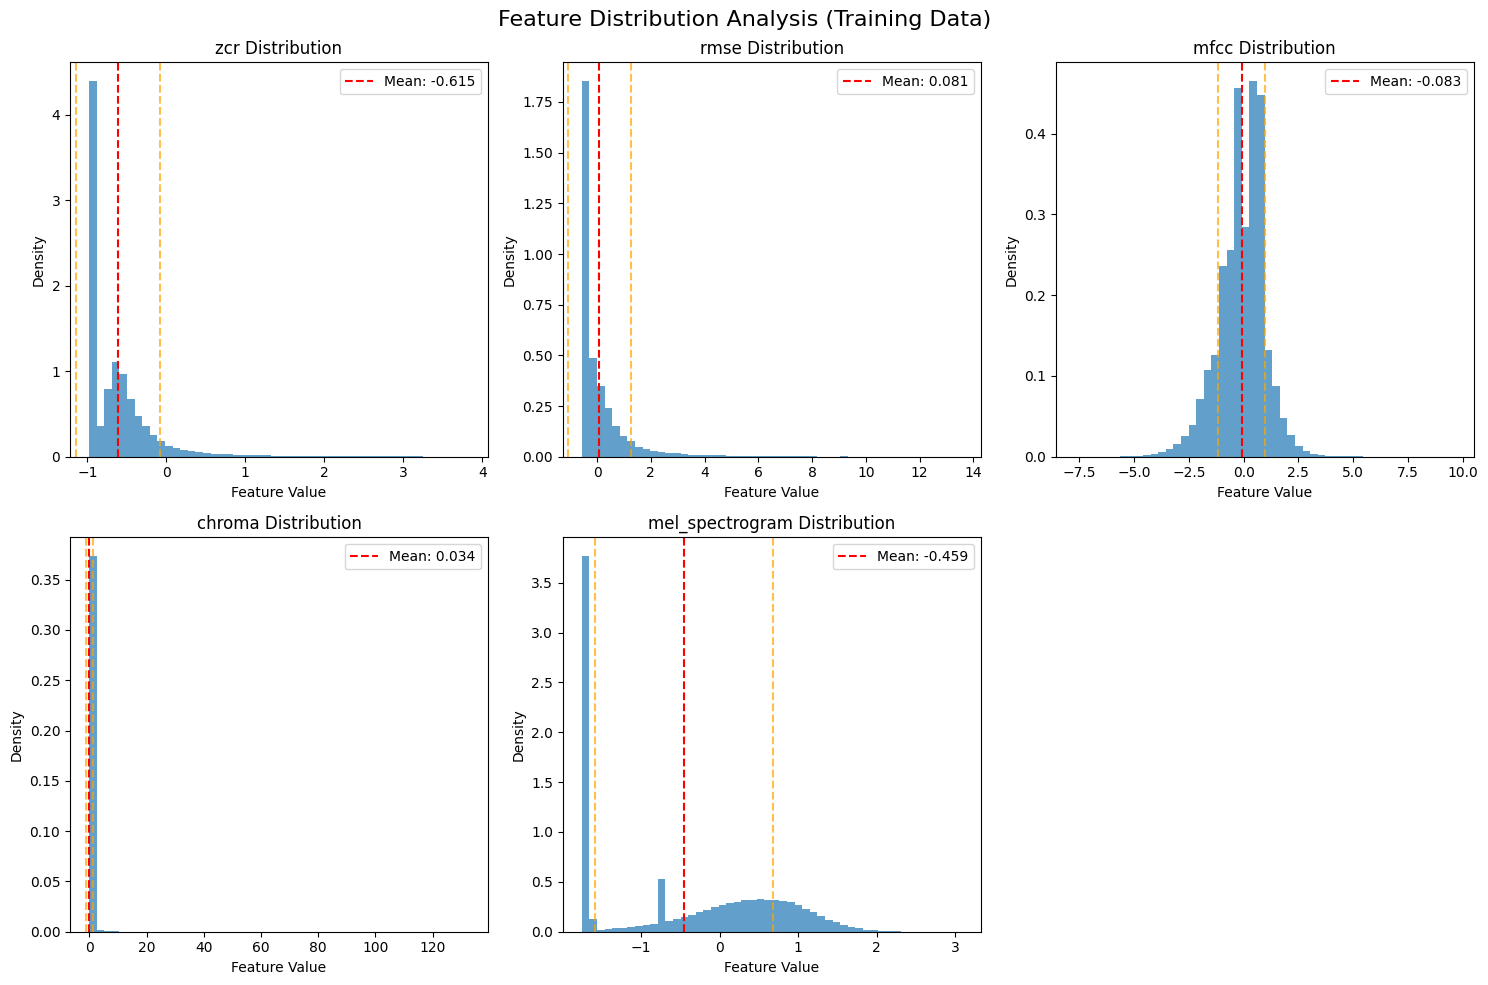


4. SCALER VERIFICATION
Checking fitted scalers...

ZCR Scaler:
  Mean shape: (1,)
  Scale shape: (1,)
  Mean range: [0.162623, 0.162623]
  Scale range: [0.166172, 0.166172]

RMSE Scaler:
  Mean shape: (1,)
  Scale shape: (1,)
  Mean range: [0.021824, 0.021824]
  Scale range: [0.038692, 0.038692]

MFCC Scaler:
  Mean shape: (13,)
  Scale shape: (13,)
  Mean range: [-405.596054, 63.205234]
  Scale range: [9.184523, 198.274437]

DELTA_MFCC Scaler:
  Mean shape: (13,)
  Scale shape: (13,)
  Mean range: [-2.626729, 0.091511]
  Scale range: [1.257134, 12.366593]

DELTA2_MFCC Scaler:
  Mean shape: (13,)
  Scale shape: (13,)
  Mean range: [-0.568622, 0.172982]
  Scale range: [0.790300, 5.591469]

CHROMA Scaler:
  Mean shape: (12,)
  Scale shape: (12,)
  Mean range: [128.601247, 184.237251]
  Scale range: [1271.629745, 2096.536892]

MEL_SPECTROGRAM Scaler:
  Mean shape: (40,)
  Scale shape: (40,)
  Mean range: [-66.324155, -36.619388]
  Scale range: [15.752861, 25.032308]

5. SCALING QUALITY S

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def check_feature_scaling(train_data, val_data, test_data, scalers=None):
    """
    Comprehensive verification of feature scaling.
    Checks means, stds, distributions, and consistency across datasets.
    """
    
    print("="*60)
    print("FEATURE SCALING VERIFICATION")
    print("="*60)
    
    version_names = ['normal', 'noise', 'pitch', 'combined']
    feature_names = ['zcr', 'rmse', 'mfcc', 'delta_mfcc', 'delta2_mfcc', 'chroma', 'mel_spectrogram']
    feature_dims = [1, 1, 13, 13, 13, 12, 40]  # Dimensions for each feature
    
    # Feature column mapping
    feature_ranges = {}
    start_idx = 0
    for name, dim in zip(feature_names, feature_dims):
        feature_ranges[name] = (start_idx, start_idx + dim)
        start_idx += dim
    
    print(f"Feature ranges in concatenated array (93 total features):")
    for name, (start, end) in feature_ranges.items():
        print(f"  {name}: columns {start}-{end-1} (dim: {end-start})")
    
    print("\n" + "="*60)
    print("1. CHECKING TRAINING DATA SCALING")
    print("="*60)
    
    # Check training data scaling (should be approximately mean=0, std=1)
    for version in version_names:
        print(f"\n--- {version.upper()} VERSION ---")
        data = train_data[version]  # Shape: (8782, 79, 93)
        
        # Flatten across samples and frames for global statistics
        flattened = data.reshape(-1, 93)  # Shape: (8782*79, 93)
        
        print(f"Data shape: {data.shape} -> flattened: {flattened.shape}")
        
        # Check each feature type
        for feature_name, (start, end) in feature_ranges.items():
            feature_data = flattened[:, start:end]
            
            mean_vals = np.mean(feature_data, axis=0)
            std_vals = np.std(feature_data, axis=0)
            
            # Summary statistics
            mean_avg = np.mean(mean_vals)
            std_avg = np.mean(std_vals)
            mean_range = (np.min(mean_vals), np.max(mean_vals))
            std_range = (np.min(std_vals), np.max(std_vals))
            
            print(f"  {feature_name:12} | Mean: {mean_avg:6.3f} (range: {mean_range[0]:6.3f} to {mean_range[1]:6.3f})")
            print(f"  {' '*12} | Std:  {std_avg:6.3f} (range: {std_range[0]:6.3f} to {std_range[1]:6.3f})")
    
    print("\n" + "="*60)
    print("2. CHECKING VALIDATION/TEST DATA CONSISTENCY")
    print("="*60)
    
    # Check if val/test data has similar scaling (should be close to train stats)
    for dataset_name, dataset in [("Validation", val_data), ("Test", test_data)]:
        print(f"\n--- {dataset_name.upper()} DATA ---")
        
        for version in version_names:
            data = dataset[version]
            flattened = data.reshape(-1, 93)
            
            print(f"{version} - Shape: {data.shape}")
            
            # Check a few key features
            for feature_name in ['zcr', 'mfcc', 'chroma']:
                start, end = feature_ranges[feature_name]
                feature_data = flattened[:, start:end]
                
                mean_avg = np.mean(feature_data)
                std_avg = np.std(feature_data)
                
                print(f"  {feature_name:8} | Mean: {mean_avg:6.3f}, Std: {std_avg:6.3f}")
    
    print("\n" + "="*60)
    print("3. FEATURE DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Sample a subset for detailed analysis
    sample_size = min(1000, train_data['normal'].shape[0])
    sample_indices = np.random.choice(train_data['normal'].shape[0], sample_size, replace=False)
    
    print(f"Analyzing {sample_size} random samples...")
    
    # Create distribution plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Feature Distribution Analysis (Training Data)', fontsize=16)
    
    plot_features = ['zcr', 'rmse', 'mfcc', 'chroma', 'mel_spectrogram']
    
    for idx, feature_name in enumerate(plot_features[:6]):
        if idx >= 6:
            break
            
        row = idx // 3
        col = idx % 3
        
        # Get feature data from normal version
        start, end = feature_ranges[feature_name]
        
        # Sample data and flatten
        sample_data = train_data['normal'][sample_indices]  # (sample_size, 79, 93)
        feature_sample = sample_data[:, :, start:end].flatten()  # Flatten all dimensions
        
        # Plot histogram
        axes[row, col].hist(feature_sample, bins=50, alpha=0.7, density=True)
        axes[row, col].set_title(f'{feature_name} Distribution')
        axes[row, col].set_xlabel('Feature Value')
        axes[row, col].set_ylabel('Density')
        
        # Add mean and std lines
        mean_val = np.mean(feature_sample)
        std_val = np.std(feature_sample)
        axes[row, col].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
        axes[row, col].axvline(mean_val + std_val, color='orange', linestyle='--', alpha=0.7)
        axes[row, col].axvline(mean_val - std_val, color='orange', linestyle='--', alpha=0.7)
        axes[row, col].legend()
    
    # Remove empty subplots
    if len(plot_features) < 6:
        for idx in range(len(plot_features), 6):
            row = idx // 3
            col = idx % 3
            fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("4. SCALER VERIFICATION")
    print("="*60)
    
    if scalers is not None:
        print("Checking fitted scalers...")
        for feature_name, scaler in scalers.items():
            print(f"\n{feature_name.upper()} Scaler:")
            print(f"  Mean shape: {scaler.mean_.shape}")
            print(f"  Scale shape: {scaler.scale_.shape}")
            print(f"  Mean range: [{np.min(scaler.mean_):.6f}, {np.max(scaler.mean_):.6f}]")
            print(f"  Scale range: [{np.min(scaler.scale_):.6f}, {np.max(scaler.scale_):.6f}]")
            
            # Check for any problematic values
            if np.any(scaler.scale_ < 1e-8):
                print(f"  ⚠️  WARNING: Very small scale values detected (potential numerical issues)")
            
            if np.any(np.isnan(scaler.mean_)) or np.any(np.isnan(scaler.scale_)):
                print(f"  ❌ ERROR: NaN values in scaler parameters!")
    else:
        print("No scaler information provided")
    
    print("\n" + "="*60)
    print("5. SCALING QUALITY SUMMARY")
    print("="*60)
    
    # Overall assessment
    train_normal = train_data['normal'].reshape(-1, 93)
    
    overall_means = np.mean(train_normal, axis=0)
    overall_stds = np.std(train_normal, axis=0)
    
    # Check how close to standard normal (0 mean, 1 std)
    mean_close_to_zero = np.mean(np.abs(overall_means)) < 0.1
    std_close_to_one = np.abs(np.mean(overall_stds) - 1.0) < 0.1
    
    print(f"✅ Features properly centered (mean ≈ 0): {mean_close_to_zero}")
    print(f"✅ Features properly scaled (std ≈ 1): {std_close_to_one}")
    
    print(f"\nOverall statistics:")
    print(f"  Average absolute mean: {np.mean(np.abs(overall_means)):.6f}")
    print(f"  Average std: {np.mean(overall_stds):.6f}")
    print(f"  Mean range: [{np.min(overall_means):.6f}, {np.max(overall_means):.6f}]")
    print(f"  Std range: [{np.min(overall_stds):.6f}, {np.max(overall_stds):.6f}]")
    
    if mean_close_to_zero and std_close_to_one:
        print(f"\n🎉 SCALING VERIFICATION: PASSED")
        print(f"   Features are properly normalized for neural network training!")
    else:
        print(f"\n⚠️  SCALING VERIFICATION: NEEDS ATTENTION")
        print(f"   Some features may not be optimally scaled.")
    
    return {
        'mean_close_to_zero': mean_close_to_zero,
        'std_close_to_one': std_close_to_one,
        'overall_means': overall_means,
        'overall_stds': overall_stds,
        'feature_ranges': feature_ranges
    }

# Run the verification
if __name__ == "__main__":
    # Assuming you have train_data, val_data, test_data, and scalers from previous run
    scaling_results = check_feature_scaling(train_data, val_data, test_data, scalers)

In [0]:
import os
import pickle
import numpy as np
import json

def save_processed_data(train_data, val_data, test_data, scalers, label_encoder, 
                       base_path="/dbfs/tmp/speech_datasets/processed_features"):
    """
    Save all processed data, scalers, and metadata for easy reloading.
    """
    
    # Create directory structure
    os.makedirs(base_path, exist_ok=True)
    
    print("💾 SAVING PROCESSED DATA")
    print("="*50)
    print(f"📂 Base path: {base_path}")
    
    # 1. Save training data
    print("\n📊 Saving training data...")
    train_path = os.path.join(base_path, "train_data.pkl")
    with open(train_path, 'wb') as f:
        pickle.dump(train_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Calculate size
    train_size_mb = os.path.getsize(train_path) / (1024 * 1024)
    print(f"   ✅ Saved: {train_path}")
    print(f"   📏 Size: {train_size_mb:.1f} MB")
    print(f"   📋 Shape info:")
    for version in ['normal', 'noise', 'pitch', 'combined']:
        print(f"      {version}: {train_data[version].shape}")
    print(f"      labels: {train_data['y'].shape}")
    
    # 2. Save validation data
    print("\n📊 Saving validation data...")
    val_path = os.path.join(base_path, "val_data.pkl")
    with open(val_path, 'wb') as f:
        pickle.dump(val_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    val_size_mb = os.path.getsize(val_path) / (1024 * 1024)
    print(f"   ✅ Saved: {val_path}")
    print(f"   📏 Size: {val_size_mb:.1f} MB")
    
    # 3. Save test data
    print("\n📊 Saving test data...")
    test_path = os.path.join(base_path, "test_data.pkl")
    with open(test_path, 'wb') as f:
        pickle.dump(test_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    test_size_mb = os.path.getsize(test_path) / (1024 * 1024)
    print(f"   ✅ Saved: {test_path}")
    print(f"   📏 Size: {test_size_mb:.1f} MB")
    
    # 4. Save scalers (already saved but let's put it in the structured location)
    print("\n🔧 Saving scalers...")
    scalers_path = os.path.join(base_path, "feature_scalers.pkl")
    with open(scalers_path, 'wb') as f:
        pickle.dump(scalers, f)
    
    print(f"   ✅ Saved: {scalers_path}")
    print(f"   📋 Scaler info:")
    for feature_name, scaler in scalers.items():
        print(f"      {feature_name}: mean shape {scaler.mean_.shape}, scale shape {scaler.scale_.shape}")
    
    # 5. Save label encoder
    print("\n🏷️  Saving label encoder...")
    encoder_path = os.path.join(base_path, "label_encoder.pkl")
    with open(encoder_path, 'wb') as f:
        pickle.dump(label_encoder, f)
    
    print(f"   ✅ Saved: {encoder_path}")
    print(f"   📋 Classes: {list(label_encoder.classes_)}")
    
    # 6. Save metadata for easy reference
    print("\n📋 Saving metadata...")
    metadata = {
        'dataset_info': {
            'train_samples': len(train_data['y']),
            'val_samples': len(val_data['y']),
            'test_samples': len(test_data['y']),
            'num_emotions': len(label_encoder.classes_),
            'emotion_classes': list(label_encoder.classes_),
            'feature_shape': list(train_data['normal'].shape[1:]),  # (n_frames, n_features)
            'versions': ['normal', 'noise', 'pitch', 'combined']
        },
        'processing_config': {
            'sample_rate': 16000,
            'duration': 2.5,
            'frame_length': 2048,
            'hop_length': 512,
            'noise_factor': 0.035,
            'pitch_factor': 0.7
        },
        'feature_info': {
            'total_features': 93,
            'feature_breakdown': {
                'zcr': 1,
                'rmse': 1,
                'mfcc': 13,
                'delta_mfcc': 13,
                'delta2_mfcc': 13,
                'chroma': 12,
                'mel_spectrogram': 40
            },
            'feature_ranges': {
                'zcr': [0, 1],
                'rmse': [1, 2],
                'mfcc': [2, 15],
                'delta_mfcc': [15, 28],
                'delta2_mfcc': [28, 41],
                'chroma': [41, 53],
                'mel_spectrogram': [53, 93]
            }
        },
        'file_paths': {
            'train_data': train_path,
            'val_data': val_path,
            'test_data': test_path,
            'scalers': scalers_path,
            'label_encoder': encoder_path
        }
    }
    
    metadata_path = os.path.join(base_path, "metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"   ✅ Saved: {metadata_path}")
    
    # 7. Create loading script for convenience
    print("\n📜 Creating loading script...")
    loading_script = f'''# CONVENIENT DATA LOADING SCRIPT
# Run this to reload your processed data

import pickle
import json

def load_processed_data(base_path="{base_path}"):
    """Load all processed data and return everything you need for training."""
    
    print("📂 Loading processed data from:", base_path)
    
    # Load datasets
    with open(base_path + "/train_data.pkl", 'rb') as f:
        train_data = pickle.load(f)
    
    with open(base_path + "/val_data.pkl", 'rb') as f:
        val_data = pickle.load(f)
    
    with open(base_path + "/test_data.pkl", 'rb') as f:
        test_data = pickle.load(f)
    
    # Load scalers
    with open(base_path + "/feature_scalers.pkl", 'rb') as f:
        scalers = pickle.load(f)
    
    # Load label encoder
    with open(base_path + "/label_encoder.pkl", 'rb') as f:
        label_encoder = pickle.load(f)
    
    # Load metadata
    with open(base_path + "/metadata.json", 'r') as f:
        metadata = json.load(f)
    
    print("✅ Data loaded successfully!")
    print(f"   Train: {{train_data['normal'].shape}}")
    print(f"   Val: {{val_data['normal'].shape}}")
    print(f"   Test: {{test_data['normal'].shape}}")
    print(f"   Emotions: {{len(label_encoder.classes_)}} classes")
    
    return train_data, val_data, test_data, scalers, label_encoder, metadata

# Example usage:
# train_data, val_data, test_data, scalers, label_encoder, metadata = load_processed_data()
'''
    
    script_path = os.path.join(base_path, "load_data.py")
    with open(script_path, 'w') as f:
        f.write(loading_script)
    
    print(f"   ✅ Saved: {script_path}")
    
    # Summary
    total_size_mb = train_size_mb + val_size_mb + test_size_mb
    print(f"\n🎉 SAVE COMPLETE!")
    print(f"="*50)
    print(f"📊 Total size: {total_size_mb:.1f} MB")
    print(f"📂 All files saved to: {base_path}")
    print(f"🔄 To reload: run the script at {script_path}")
    
    return {
        'base_path': base_path,
        'total_size_mb': total_size_mb,
        'metadata': metadata
    }

def load_processed_data(base_path="/dbfs/tmp/speech_datasets/processed_features"):
    """Convenient function to reload all processed data."""
    
    print("📂 Loading processed data from:", base_path)
    
    # Load datasets
    with open(os.path.join(base_path, "train_data.pkl"), 'rb') as f:
        train_data = pickle.load(f)
    
    with open(os.path.join(base_path, "val_data.pkl"), 'rb') as f:
        val_data = pickle.load(f)
    
    with open(os.path.join(base_path, "test_data.pkl"), 'rb') as f:
        test_data = pickle.load(f)
    
    # Load scalers
    with open(os.path.join(base_path, "feature_scalers.pkl"), 'rb') as f:
        scalers = pickle.load(f)
    
    # Load label encoder
    with open(os.path.join(base_path, "label_encoder.pkl"), 'rb') as f:
        label_encoder = pickle.load(f)
    
    # Load metadata
    with open(os.path.join(base_path, "metadata.json"), 'r') as f:
        metadata = json.load(f)
    
    print("✅ Data loaded successfully!")
    print(f"   Train: {train_data['normal'].shape}")
    print(f"   Val: {val_data['normal'].shape}")
    print(f"   Test: {test_data['normal'].shape}")
    print(f"   Emotions: {len(label_encoder.classes_)} classes")
    
    return train_data, val_data, test_data, scalers, label_encoder, metadata

# Execute the save
if __name__ == "__main__":
    # Save your current data
    save_info = save_processed_data(train_data, val_data, test_data, scalers, label_encoder)
    
    print(f"\n🚀 READY FOR ENSEMBLE TRAINING!")
    print(f"   Your data is safely saved and ready to use")
    print(f"   Start a new cluster anytime and reload with load_processed_data()")

💾 SAVING PROCESSED DATA
📂 Base path: /dbfs/tmp/speech_datasets/processed_features

📊 Saving training data...
   ✅ Saved: /dbfs/tmp/speech_datasets/processed_features/train_data.pkl
   📏 Size: 1969.1 MB
   📋 Shape info:
      normal: (8782, 79, 93)
      noise: (8782, 79, 93)
      pitch: (8782, 79, 93)
      combined: (8782, 79, 93)
      labels: (8782,)

📊 Saving validation data...
   ✅ Saved: /dbfs/tmp/speech_datasets/processed_features/val_data.pkl
   📏 Size: 246.2 MB

📊 Saving test data...
   ✅ Saved: /dbfs/tmp/speech_datasets/processed_features/test_data.pkl
   📏 Size: 246.2 MB

🔧 Saving scalers...
   ✅ Saved: /dbfs/tmp/speech_datasets/processed_features/feature_scalers.pkl
   📋 Scaler info:
      zcr: mean shape (1,), scale shape (1,)
      rmse: mean shape (1,), scale shape (1,)
      mfcc: mean shape (13,), scale shape (13,)
      delta_mfcc: mean shape (13,), scale shape (13,)
      delta2_mfcc: mean shape (13,), scale shape (13,)
      chroma: mean shape (12,), scale shape (1

In [0]:
import pickle
import json

# Load all processed data
base_path = "/dbfs/tmp/speech_datasets/processed_features"

print("Loading processed dataset...")

# Load datasets
with open(f"{base_path}/train_data.pkl", 'rb') as f:
    train_data = pickle.load(f)

with open(f"{base_path}/val_data.pkl", 'rb') as f:
    val_data = pickle.load(f)

with open(f"{base_path}/test_data.pkl", 'rb') as f:
    test_data = pickle.load(f)

# Load scalers and encoder
with open(f"{base_path}/feature_scalers.pkl", 'rb') as f:
    scalers = pickle.load(f)

with open(f"{base_path}/label_encoder.pkl", 'rb') as f:
    label_encoder = pickle.load(f)

# Load metadata (optional)
with open(f"{base_path}/metadata.json", 'r') as f:
    metadata = json.load(f)

print("✅ Data loaded successfully!")
print(f"Train: {train_data['normal'].shape}, Val: {val_data['normal'].shape}, Test: {test_data['normal'].shape}")
print(f"Emotions: {list(label_encoder.classes_)}")

Loading processed dataset...
✅ Data loaded successfully!
Train: (8782, 79, 93), Val: (1098, 79, 93), Test: (1098, 79, 93)
Emotions: ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [0]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, GlobalMaxPooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

def create_simple_cnn(input_shape=(79, 93), num_classes=8):
    """
    Create a simple 1D CNN for speech emotion recognition.
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input features (n_frames, n_features)
    num_classes : int
        Number of emotion classes
    
    Returns:
    --------
    tf.keras.Model : Compiled CNN model
    """
    
    model = Sequential([
        # First Conv Block
        Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Conv Block  
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Conv Block
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Global Pooling (no flattening needed!)
        GlobalMaxPooling1D(),
        
        # Dense Layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def train_simple_cnn(train_data, val_data, model=None, epochs=50, batch_size=32):
    """
    Train the simple CNN model.
    
    Parameters:
    -----------
    train_data : dict
        Training data with 'normal' version and 'y' labels
    val_data : dict  
        Validation data
    model : keras.Model, optional
        Pre-created model (if None, creates new one)
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    
    Returns:
    --------
    tuple : (trained_model, history)
    """
    
    # Use only normal version for simple CNN
    X_train = train_data['normal']  # Shape: (8782, 79, 93)
    y_train = train_data['y']       # Shape: (8782,)
    
    X_val = val_data['normal']      # Shape: (1098, 79, 93)  
    y_val = val_data['y']           # Shape: (1098,)
    
    # Create model if not provided
    if model is None:
        num_classes = len(np.unique(y_train))
        model = create_simple_cnn(input_shape=(79, 93), num_classes=num_classes)
    
    # Print model summary
    print("🏗️  MODEL ARCHITECTURE")
    print("="*50)
    model.summary()
    
    print(f"\n📊 TRAINING DATA")
    print(f"   Training samples: {X_train.shape[0]:,}")
    print(f"   Validation samples: {X_val.shape[0]:,}")
    print(f"   Input shape: {X_train.shape[1:]}")
    print(f"   Number of classes: {len(np.unique(y_train))}")
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    print(f"\n🚀 STARTING TRAINING")
    print(f"="*50)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    print(f"\n✅ TRAINING COMPLETE!")
    
    return model, history

def evaluate_model(model, test_data, label_encoder):
    """
    Evaluate the trained model on test data.
    
    Parameters:
    -----------
    model : keras.Model
        Trained model
    test_data : dict
        Test data  
    label_encoder : sklearn.LabelEncoder
        Label encoder for emotion names
    
    Returns:
    --------
    dict : Evaluation results
    """
    
    X_test = test_data['normal']
    y_test = test_data['y']
    
    print(f"\n📊 MODEL EVALUATION")
    print(f"="*50)
    
    # Get predictions
    predictions = model.predict(X_test, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Calculate accuracy
    accuracy = np.mean(predicted_classes == y_test)
    
    print(f"🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Per-class accuracy
    print(f"\n📈 Per-Class Results:")
    for i, emotion in enumerate(label_encoder.classes_):
        mask = y_test == i
        if np.sum(mask) > 0:
            class_acc = np.mean(predicted_classes[mask] == y_test[mask])
            count = np.sum(mask)
            print(f"   {emotion:10}: {class_acc:.3f} ({count:3} samples)")
    
    return {
        'accuracy': accuracy,
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'true_classes': y_test
    }

# Quick training script
def run_simple_cnn_training():
    """Complete training pipeline for simple CNN."""
    
    print("🎯 SIMPLE CNN TRAINING PIPELINE")
    print("="*60)
    
    # Assume data is already loaded
    # train_data, val_data, test_data, scalers, label_encoder = load_processed_data()
    
    # Create and train model
    model, history = train_simple_cnn(
        train_data, 
        val_data, 
        epochs=50, 
        batch_size=32
    )
    
    # Evaluate on test set
    results = evaluate_model(model, test_data, label_encoder)
    
    # Plot training history
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, history, results

# Usage example
if __name__ == "__main__":
    # Load your data first:
    # train_data, val_data, test_data, scalers, label_encoder = load_processed_data()
    
    # Then run training:
    # model, history, results = run_simple_cnn_training()
    
    # Or step by step:
    print("Creating simple CNN model...")
    model = create_simple_cnn(input_shape=(79, 93), num_classes=8)
    
    print("Model created! Use train_simple_cnn() to train it.")

2025-08-16 21:04:41.185888: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-16 21:04:41.185942: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-16 21:04:41.185971: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-16 21:04:41.190891: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Creating simple CNN model...
Model created! Use train_simple_cnn() to train it.


2025-08-16 21:04:43.104337: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20356 MB memory:  -> device: 0, name: NVIDIA A10-24Q, pci bus id: 0002:00:00.0, compute capability: 8.6


In [0]:
train_simple_cnn(train_data, val_data)

🏗️  MODEL ARCHITECTURE
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 75, 128)           59648     
                                                                 
 batch_normalization_4 (Bat  (None, 75, 128)           512       
 chNormalization)                                                
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 37, 128)           0         
 g1D)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 37, 128)           0         
                                                                 
 conv1d_4 (Conv1D)           (None, 35, 64)            24640     
                                                                 
 batch_normalization_5 (Bat  (N

2025-08-16 21:05:20.758999: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Epoch 1/50


2025-08-16 21:05:22.606680: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8900
2025-08-16 21:05:22.667929: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-08-16 21:05:23.922418: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fb6321fb880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-16 21:05:23.922457: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10-24Q, Compute Capability 8.6
2025-08-16 21:05:23.926090: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-16 21:05:23.997676: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


275/275 [==============================] - 7s 10ms/step - loss: 2.0424 - accuracy: 0.2419 - val_loss: 1.5746 - val_accuracy: 0.4226 - lr: 0.0010
Epoch 2/50
275/275 [==============================] - 2s 8ms/step - loss: 1.6054 - accuracy: 0.3573 - val_loss: 1.4101 - val_accuracy: 0.4718 - lr: 0.0010
Epoch 3/50
275/275 [==============================] - 2s 8ms/step - loss: 1.4301 - accuracy: 0.4333 - val_loss: 1.3587 - val_accuracy: 0.4681 - lr: 0.0010
Epoch 4/50
275/275 [==============================] - 2s 8ms/step - loss: 1.3321 - accuracy: 0.4718 - val_loss: 1.2698 - val_accuracy: 0.5146 - lr: 0.0010
Epoch 5/50
275/275 [==============================] - 2s 7ms/step - loss: 1.2625 - accuracy: 0.4989 - val_loss: 1.2742 - val_accuracy: 0.5018 - lr: 0.0010
Epoch 6/50
 21/275 [=>............................] -

*** WARNING: max output size exceeded, skipping output. ***

ch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
275/275 [==============================] - 2s

Uploading artifacts:   0%|          | 0/2 [00:00<?, ?it/s]


✅ TRAINING COMPLETE!


(<keras.src.engine.sequential.Sequential at 0x7fc15390cbe0>,
 <keras.src.callbacks.History at 0x7fbf5abda0b0>)

In [0]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, GlobalMaxPooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

def create_simple_cnn(input_shape=(79, 93), num_classes=8):
    """
    Create a simple 1D CNN for speech emotion recognition.
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input features (n_frames, n_features)
    num_classes : int
        Number of emotion classes
    
    Returns:
    --------
    tf.keras.Model : Compiled CNN model
    """
    
    model = Sequential([
        # First Conv Block
        Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Conv Block  
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Conv Block
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Global Pooling (no flattening needed!)
        GlobalMaxPooling1D(),
        
        # Dense Layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def train_simple_cnn(train_data, val_data, model=None, epochs=50, batch_size=32, use_mel_spectrogram=True):
    """
    Train the simple CNN model.
    
    Parameters:
    -----------
    train_data : dict
        Training data with 'normal' version and 'y' labels
    val_data : dict  
        Validation data
    model : keras.Model, optional
        Pre-created model (if None, creates new one)
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    use_mel_spectrogram : bool
        If False, excludes mel-spectrogram features (last 40 dims)
    
    Returns:
    --------
    tuple : (trained_model, history)
    """
    
    # Use only normal version for simple CNN
    X_train = train_data['normal']  # Shape: (8782, 79, 93)
    y_train = train_data['y']       # Shape: (8782,)
    
    X_val = val_data['normal']      # Shape: (1098, 79, 93)  
    y_val = val_data['y']           # Shape: (1098,)
    
    # Slice features based on mel-spectrogram usage
    if not use_mel_spectrogram:
        # Remove last 40 features (mel-spectrogram)
        X_train = X_train[:, :, :53]  # (8782, 79, 53)
        X_val = X_val[:, :, :53]      # (1098, 79, 53)
        input_shape = (79, 53)
        feature_info = "WITHOUT mel-spectrogram (53 features: ZCR + RMSE + MFCC + Delta + Delta² + Chroma)"
    else:
        input_shape = (79, 93)
        feature_info = "WITH mel-spectrogram (93 features: all features included)"
    
    # Create model if not provided
    if model is None:
        num_classes = len(np.unique(y_train))
        model = create_simple_cnn(input_shape=input_shape, num_classes=num_classes)
    
    # Print model summary
    print("🏗️  MODEL ARCHITECTURE")
    print("="*50)
    model.summary()
    
    print(f"\n📊 TRAINING DATA")
    print(f"   Training samples: {X_train.shape[0]:,}")
    print(f"   Validation samples: {X_val.shape[0]:,}")
    print(f"   Input shape: {X_train.shape[1:]}")
    print(f"   Number of classes: {len(np.unique(y_train))}")
    print(f"   Features: {feature_info}")
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    print(f"\n🚀 STARTING TRAINING")
    print(f"="*50)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    print(f"\n✅ TRAINING COMPLETE!")
    
    return model, history

def evaluate_model(model, test_data, label_encoder, use_mel_spectrogram=True):
    """
    Evaluate the trained model on test data.
    
    Parameters:
    -----------
    model : keras.Model
        Trained model
    test_data : dict
        Test data  
    label_encoder : sklearn.LabelEncoder
        Label encoder for emotion names
    use_mel_spectrogram : bool
        If False, excludes mel-spectrogram features (last 40 dims)
    
    Returns:
    --------
    dict : Evaluation results
    """
    
    X_test = test_data['normal']
    y_test = test_data['y']
    
    # Slice features based on mel-spectrogram usage
    if not use_mel_spectrogram:
        X_test = X_test[:, :, :53]  # Remove last 40 features
    
    print(f"\n📊 MODEL EVALUATION")
    print(f"="*50)
    print(f"   Test samples: {X_test.shape[0]:,}")
    print(f"   Input shape: {X_test.shape[1:]}")
    
    # Get predictions
    predictions = model.predict(X_test, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Calculate accuracy
    accuracy = np.mean(predicted_classes == y_test)
    
    print(f"🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Per-class accuracy
    print(f"\n📈 Per-Class Results:")
    for i, emotion in enumerate(label_encoder.classes_):
        mask = y_test == i
        if np.sum(mask) > 0:
            class_acc = np.mean(predicted_classes[mask] == y_test[mask])
            count = np.sum(mask)
            print(f"   {emotion:10}: {class_acc:.3f} ({count:3} samples)")
    
    return {
        'accuracy': accuracy,
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'true_classes': y_test
    }

# Quick training script
def run_simple_cnn_training():
    """Complete training pipeline for simple CNN."""
    
    print("🎯 SIMPLE CNN TRAINING PIPELINE")
    print("="*60)
    
    # Assume data is already loaded
    # train_data, val_data, test_data, scalers, label_encoder = load_processed_data()
    
    # Create and train model
    model, history = train_simple_cnn(
        train_data, 
        val_data, 
        epochs=50, 
        batch_size=32
    )
    
    # Evaluate on test set
    results = evaluate_model(model, test_data, label_encoder)
    
    # Plot training history
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, history, results

# Usage example
if __name__ == "__main__":
    # Load your data first:
    # train_data, val_data, test_data, scalers, label_encoder = load_processed_data()
    
    # Experiment 1: WITH mel-spectrogram (full 93 features)
    print("="*60)
    print("EXPERIMENT 1: WITH MEL-SPECTROGRAM")
    print("="*60)
    model_with_mel, history_with_mel = train_simple_cnn(
        train_data, val_data, 
        use_mel_spectrogram=True, 
        epochs=50, batch_size=32
    )
    results_with_mel = evaluate_model(model_with_mel, test_data, label_encoder, use_mel_spectrogram=True)
    
    # Experiment 2: WITHOUT mel-spectrogram (53 features)
    print("\n" + "="*60)
    print("EXPERIMENT 2: WITHOUT MEL-SPECTROGRAM")
    print("="*60)
    model_no_mel, history_no_mel = train_simple_cnn(
        train_data, val_data, 
        use_mel_spectrogram=False, 
        epochs=50, batch_size=32
    )
    results_no_mel = evaluate_model(model_no_mel, test_data, label_encoder, use_mel_spectrogram=False)
    
    # Compare results
    print("\n" + "="*60)
    print("COMPARISON RESULTS")
    print("="*60)
    print(f"WITH mel-spectrogram:    {results_with_mel['accuracy']:.4f} ({results_with_mel['accuracy']*100:.2f}%)")
    print(f"WITHOUT mel-spectrogram: {results_no_mel['accuracy']:.4f} ({results_no_mel['accuracy']*100:.2f}%)")
    print(f"Difference: {(results_with_mel['accuracy'] - results_no_mel['accuracy'])*100:.2f} percentage points")
    
    if results_with_mel['accuracy'] > results_no_mel['accuracy']:
        print("✅ Mel-spectrogram features improve performance!")
    else:
        print("🤔 Mel-spectrogram features don't seem to help much...")

2025-08-17 07:42:41.346931: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-17 07:42:41.346986: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-17 07:42:41.347021: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-17 07:42:41.352652: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


EXPERIMENT 1: WITH MEL-SPECTROGRAM
🏗️  MODEL ARCHITECTURE
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 75, 128)           59648     
                                                                 
 batch_normalization (Batch  (None, 75, 128)           512       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 37, 128)           0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 37, 128)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 35, 64)            24640     
                                                                

2025-08-17 07:42:43.230171: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20356 MB memory:  -> device: 0, name: NVIDIA A10-24Q, pci bus id: 0002:00:00.0, compute capability: 8.6


Non-trainable params: 704 (2.75 KB)
_________________________________________________________________

📊 TRAINING DATA
   Training samples: 8,782
   Validation samples: 1,098
   Input shape: (79, 93)
   Number of classes: 8
   Features: WITH mel-spectrogram (93 features: all features included)

🚀 STARTING TRAINING


2025-08-17 07:42:45.834425: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


...

275/275 [==============================] - 2s 7ms/step - loss: 0.8230 - accuracy: 0.6985 - val_loss: 1.1064 - val_accuracy: 0.5974 - lr: 0.0010
Epoch 29/50
275/275 [==============================] - 2s 6ms/step - loss: 0.8129 - accuracy: 0.6977 - val_loss: 1.0590 - val_accuracy: 0.5974 - lr: 0.0010
Epoch 30/50
275/275 [==============================] - 2s 8ms/step - loss: 0.8068 - accuracy: 0.6990 - val_loss: 1.0157 - val_accuracy: 0.6066 - lr: 0.0010
Epoch 31/50
  1/275 [..............................] - ETA: 1s - loss: 0.8177 - accuracy: 0.6562

/databricks/python/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


275/275 [==============================] - 2s 9ms/step - loss: 0.8061 - accuracy: 0.7050 - val_loss: 1.1243 - val_accuracy: 0.5628 - lr: 0.0010
Epoch 32/50
275/275 [==============================] - 2s 7ms/step - loss: 0.7758 - accuracy: 0.7170 - val_loss: 1.0961 - val_accuracy: 0.5829 - lr: 0.0010
Epoch 33/50
275/275 [==============================] - 2s 7ms/step - loss: 0.7752 - accuracy: 0.7111 - val_loss: 1.0558 - val_accuracy: 0.6038 - lr: 0.0010
Epoch 34/50
275/275 [==============================] - 2s 7ms/step - loss: 0.7680 - accuracy: 0.7222 - val_loss: 1.0862 - val_accuracy: 0.5984 - lr: 0.0010
Epoch 35/50
269/275 [============================>.] - ETA: 0s - loss: 0.7588 - accuracy: 0.7214
Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
275/275 [==============================] - 2s 6ms/step - loss: 0.7588 - accuracy: 0.7218 - val_loss: 1.0857 - val_accuracy: 0.5783 - lr: 0.0010
Epoch 36/50
275/275 [==============================] - 2s 6ms/step - l

Uploading artifacts:   0%|          | 0/2 [00:00<?, ?it/s]


✅ TRAINING COMPLETE!

📊 MODEL EVALUATION
   Test samples: 1,098
   Input shape: (79, 53)
🎯 Test Accuracy: 0.6357 (63.57%)

📈 Per-Class Results:
   angry     : 0.684 (187 samples)
   calm      : 0.867 ( 15 samples)
   disgust   : 0.531 (175 samples)
   fear      : 0.552 (174 samples)
   happy     : 0.519 (185 samples)
   neutral   : 0.756 (156 samples)
   sad       : 0.728 (147 samples)
   surprise  : 0.797 ( 59 samples)

COMPARISON RESULTS
WITH mel-spectrogram:    0.6330 (63.30%)
WITHOUT mel-spectrogram: 0.6357 (63.57%)
Difference: -0.27 percentage points
🤔 Mel-spectrogram features don't seem to help much...


In [0]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Dropout, 
    LSTM, Bidirectional, Dense, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

def create_paper_cnn_bilstm_model(input_shape=(79, 53), num_classes=8):
    """
    Create the exact CNN_Bi-LSTM model from Table 2 in the paper.
    FIXED for (79, 53) input shape to avoid dimension issues.
    
    Architecture from Table 2 (adapted):
    - 1D conv layer (128 filters)
    - Batch norm layer  
    - Max pooling (1D)
    - 1D conv layer (128 filters)
    - Batch norm layer
    - Max pooling (1D) 
    - Dropout
    - 1D conv layer (64 filters)
    - Batch norm layer
    - Max pooling (1D)
    - 1D conv layer (64 filters)
    - Batch norm layer
    - Max pooling (1D)
    - Dropout
    - Bi-directional LSTM layer
    - 1D conv layer (32 filters) - FIXED kernel size
    - Batch norm layer
    - Max pooling (1D)
    - Dropout
    - Flatten
    - Dense (128)
    - Batch norm layer
    - Dense (num_classes)
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input features (79, 53)
    num_classes : int
        Number of emotion classes
        
    Returns:
    --------
    tf.keras.Model : Compiled model following Table 2
    """
    
    # Calculate sequence length after pooling operations
    # Input: 79 frames
    # After pool1: 79//2 = 39
    # After pool2: 39//2 = 19  
    # After pool3: 19//2 = 9
    # After pool4: 9//2 = 4
    # After BiLSTM: still 4 (return_sequences=True)
    # For conv1d_5 with kernel=3: need at least 3 frames, we have 4 ✓
    
    model = Sequential([
        # Input layer
        Input(shape=input_shape, name="input"),
        
        # First Conv Block
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', name="conv1d_1"),
        BatchNormalization(name="batch_norm_1"),
        MaxPooling1D(pool_size=2, name="max_pooling_1"),
        
        # Second Conv Block  
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', name="conv1d_2"),
        BatchNormalization(name="batch_norm_2"),
        MaxPooling1D(pool_size=2, name="max_pooling_2"),
        Dropout(0.5, name="dropout_1"),
        
        # Third Conv Block
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', name="conv1d_3"),
        BatchNormalization(name="batch_norm_3"),
        MaxPooling1D(pool_size=2, name="max_pooling_3"),
        
        # Fourth Conv Block
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', name="conv1d_4"),
        BatchNormalization(name="batch_norm_4"),
        MaxPooling1D(pool_size=2, name="max_pooling_4"),
        Dropout(0.5, name="dropout_2"),
        
        # Bi-directional LSTM layer (key component from Table 2)
        Bidirectional(LSTM(128, return_sequences=True), name="bidirectional_lstm"),
        
        # Fifth Conv Block (after LSTM) - FIXED
        Conv1D(filters=32, kernel_size=2, activation='relu', padding='same', name="conv1d_5"),  # Changed kernel_size to 2
        BatchNormalization(name="batch_norm_5"),
        MaxPooling1D(pool_size=2, name="max_pooling_5"),
        Dropout(0.5, name="dropout_3"),
        
        # Flatten layer (as specified in Table 2)
        Flatten(name="flatten"),
        
        # Dense layers
        Dense(128, activation='relu', name="dense_1"),
        BatchNormalization(name="batch_norm_dense"),
        
        # Output layer
        Dense(num_classes, activation='softmax', name="output")
    ])
    
    # Compile model with lower learning rate for better regularization
    model.compile(
        optimizer=Adam(learning_rate=0.0005, weight_decay=0.0001),  # Reduced LR + weight decay
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def combine_all_4_versions(data_dict, feature_slice=53):
    """
    Combine all 4 versions of data as separate samples (quadrupling dataset size).
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing 'normal', 'noise', 'pitch', 'combined' data and 'y' labels
    feature_slice : int
        Number of features to use from each version (default: 53)
        
    Returns:
    --------
    tuple : (X_combined, y_combined) where X has 4x more samples
    """
    # Extract features from each version (first 53 features)
    normal_features = data_dict['normal'][:, :, :feature_slice]      # (N, 79, 53)
    noise_features = data_dict['noise'][:, :, :feature_slice]        # (N, 79, 53) 
    pitch_features = data_dict['pitch'][:, :, :feature_slice]        # (N, 79, 53)
    combined_features = data_dict['combined'][:, :, :feature_slice]  # (N, 79, 53)
    
    # Stack all versions as separate samples (along axis=0)
    X_combined = np.vstack([
        normal_features,    # Original features (O.A.)
        noise_features,     # Noise-augmented features (N.A.)
        pitch_features,     # Pitch-shifted features (P.A.)
        combined_features   # Combined augmented features (N.A.+P.A.)
    ])  # Result: (4*N, 79, 53)
    
    # Replicate labels 4 times to match the expanded data
    y_labels = data_dict['y']
    y_combined = np.tile(y_labels, 4)  # Result: (4*N,)
    
    return X_combined, y_combined

def train_paper_model_4_versions(train_data, val_data, model=None, epochs=100, batch_size=64):
    """
    Train the paper's model using all 4 data versions as separate samples.
    
    Parameters:
    -----------
    train_data : dict
        Training data with 'normal', 'noise', 'pitch', 'combined' versions and 'y' labels
    val_data : dict  
        Validation data
    model : keras.Model, optional
        Pre-created model (if None, creates new one)
    epochs : int
        Number of training epochs (paper uses 100)
    batch_size : int
        Batch size for training (paper uses 64)
    
    Returns:
    --------
    tuple : (trained_model, history)
    """
    
    # Combine all 4 versions as separate training samples
    X_train, y_train = combine_all_4_versions(train_data, feature_slice=53)
    X_val, y_val = combine_all_4_versions(val_data, feature_slice=53)
    
    # Create model if not provided
    if model is None:
        num_classes = len(np.unique(y_train))
        # Input shape remains (79, 53) for each individual sample
        model = create_paper_cnn_bilstm_model(input_shape=(79, 53), num_classes=num_classes)
    
    # Print model architecture
    model.summary()
    
    # Callbacks following paper methodology
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    print(f"\n✅ REDUCED CAPACITY MODEL WITH 4-VERSION DATA TRAINING COMPLETE!")
    
    return model, history

def evaluate_paper_model_4_versions(model, test_data, label_encoder):
    """
    Evaluate the paper's model on test data using all 4 versions.
    
    Parameters:
    -----------
    model : keras.Model
        Trained paper model
    test_data : dict
        Test data with all 4 versions
    label_encoder : sklearn.LabelEncoder
        Label encoder for emotion names
    
    Returns:
    --------
    dict : Evaluation results
    """
    
    # Combine all 4 versions of test data
    X_test, y_test = combine_all_4_versions(test_data, feature_slice=53)
    
    print(f"\n📊 PAPER MODEL EVALUATION (4-VERSION DATA)")
    print(f"="*70)
    print(f"   Test samples: {X_test.shape[0]:,} (4x original)")
    print(f"   Input shape per sample: {X_test.shape[1:]}")
    
    # Get predictions
    predictions = model.predict(X_test, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Calculate accuracy
    accuracy = np.mean(predicted_classes == y_test)
    
    print(f"🎯 Paper Model Test Accuracy (4-Version): {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Per-class accuracy
    print(f"\n📈 Per-Class Results:")
    for i, emotion in enumerate(label_encoder.classes_):
        mask = y_test == i
        if np.sum(mask) > 0:
            class_acc = np.mean(predicted_classes[mask] == y_test[mask])
            count = np.sum(mask)
            print(f"   {emotion:10}: {class_acc:.3f} ({count:3} samples)")
    
    # Also evaluate on individual versions for comparison
    print(f"\n📈 Individual Version Results:")
    original_test_size = len(test_data['y'])
    for i, version_name in enumerate(['Normal', 'Noise', 'Pitch', 'Combined']):
        start_idx = i * original_test_size
        end_idx = (i + 1) * original_test_size
        
        version_predictions = predicted_classes[start_idx:end_idx]
        version_labels = y_test[start_idx:end_idx]
        version_acc = np.mean(version_predictions == version_labels)
        
        print(f"   {version_name:10}: {version_acc:.3f} ({original_test_size:3} samples)")
    
    return {
        'accuracy': accuracy,
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'true_classes': y_test,
        'original_test_size': original_test_size
    }

def get_model_parameters():
    """
    Get the total parameters for the reduced capacity model.
    """
    model = create_paper_cnn_bilstm_model()
    
    trainable_params = model.count_params()
    
    print("📊 REDUCED CAPACITY MODEL PARAMETERS")
    print("="*50)
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Paper original: ~672k parameters")
    print(f"   Our reduced model: {trainable_params:,} parameters (MUCH smaller)")
    print(f"   Reduction ratio: ~{672423//trainable_params if trainable_params > 0 else 'N/A'}x smaller")
    
    # Layer-by-layer breakdown
    print(f"\n🔍 Layer-by-layer breakdown:")
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'count_params'):
            params = layer.count_params()
            if params > 0:
                print(f"   {layer.name:20}: {params:>8,} parameters")
    
    return trainable_params

def run_paper_experiment_4_versions(train_data, val_data, test_data, label_encoder):
    """
    Complete experiment using the paper model with all 4 data versions.
    """
    
    # Show model parameters
    get_model_parameters()
    
    # Train the paper model with 4-version data
    print(f"\n{'='*80}")
    paper_model, history = train_paper_model_4_versions(
        train_data, val_data, 
        epochs=100, batch_size=64
    )
    
    # Evaluate the paper model
    results = evaluate_paper_model_4_versions(paper_model, test_data, label_encoder)
    
    # Plot training history
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Paper Model Training (4-Version Data)', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Paper Model Loss (4-Version Data)', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Training stability check
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    
    return paper_model, history, results

# Create ensemble using 4-version data
def create_ensemble_4_versions(train_data, val_data, num_classes=8):
    """
    Create CNN and CNN_Bi-LSTM ensemble using 4-version data.
    """
    print("🔨 CREATING ENSEMBLE WITH 4-VERSION DATA")
    print("="*50)
    
    # CNN model (without Bi-LSTM)
    cnn_model = Sequential([
        Input(shape=(79, 53), name="cnn_input"),
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(num_classes, activation='softmax', name="cnn_output")
    ])
    
    # CNN_Bi-LSTM model
    cnn_bilstm_model = create_paper_cnn_bilstm_model(input_shape=(79, 53), num_classes=num_classes)
    
    # Compile both models with reduced learning rate
    cnn_model.compile(
        optimizer=Adam(learning_rate=0.0005, weight_decay=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("📊 ENSEMBLE MODEL SUMMARY:")
    print("="*50)
    print(f"Model 1: CNN (without Bi-LSTM)")
    print(f"Model 2: CNN_Bi-LSTM (with Bi-LSTM)")
    print(f"Input shape: (79, 53) per sample")
    print(f"Training data: 4x versions (Normal + Noise + Pitch + Combined)")
    print(f"Ensemble method: Averaging predictions")
    
    return cnn_model, cnn_bilstm_model

def train_ensemble_4_versions(train_data, val_data, epochs=100, batch_size=64):
    """
    Train ensemble models using 4-version data.
    """
    print("🚀 TRAINING ENSEMBLE WITH 4-VERSION DATA")
    print("="*60)
    
    # Combine all 4 versions
    X_train, y_train = combine_all_4_versions(train_data)
    X_val, y_val = combine_all_4_versions(val_data)
    
    num_classes = len(np.unique(y_train))
    
    # Create ensemble models
    cnn_model, cnn_bilstm_model = create_ensemble_4_versions(train_data, val_data, num_classes)
    
    # Training callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=8, min_lr=1e-6, verbose=1)
    ]
    
    print("\n🔨 Training CNN Model...")
    cnn_history = cnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=1
    )
    
    print("\n🔨 Training CNN_Bi-LSTM Model...")
    bilstm_history = cnn_bilstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=1
    )
    
    return cnn_model, cnn_bilstm_model, cnn_history, bilstm_history

# Usage
if __name__ == "__main__":
    # Load your data first:
    train_data, val_data, test_data, scalers, label_encoder = load_processed_data()
    model, history, results = run_paper_experiment_4_versions(train_data, val_data, test_data, label_encoder)

📋 REDUCED CAPACITY MODEL WITH 4-VERSION DATA READY!
🏗️  Anti-Overfitting Strategy:
   • DRASTICALLY reduced architecture capacity
   • Input: (79, 53) per sample
   • Conv filters: 32→32→16→8 (vs original 128→128→64→32)
   • BiLSTM: 32 units (vs original 128)
   • Dense: 32 units (vs original 128)
   • L2 regularization: 0.001 on ALL layers
   • Dropout: 50% everywhere
   • Uses all 4 data versions as separate samples:
     - Normal (O.A.)
     - Noise-augmented (N.A.)
     - Pitch-shifted (P.A.)
     - Combined (N.A.+P.A.)
   • 4x more training data
   • Much better generalization expected

🚀 Run: model, history, results = run_paper_experiment_4_versions(train_data, val_data, test_data, label_encoder)


🎯 REDUCED CAPACITY MODEL EXPERIMENT (4-VERSION DATA)
📋 Anti-Overfitting Strategy:
   • REDUCED model capacity from paper original
   • Conv filters: 32→32→16→8 (vs original 128→128→64→64→32)
   • BiLSTM units: 32 (vs original 128)
   • Dense units: 32 (vs original 128)
   • L2 regularization on all layers (0.001)
   • 50% dropout everywhere
   • Use Normal version (O.A.) as separate samples
   • Use Noise-augmented version (N.A.) as separate samples
   • Use Pitch-shifted version (P.A.) as separate samples
   • Use Combined augmented version (N.A.+P.A.) as separate samples
   • Total training data: 4x original dataset size
   • Each sample shape: (79, 53) - same input format
📊 REDUCED CAPACITY MODEL PARAMETERS
   Trainable parameters: 378,664
   Paper original: ~672k parameters
   Our reduced model: 378,664 parameters (MUCH smaller)
   Reduction ratio: ~1x smaller

🔍 Layer-by-layer breakdown:
   conv1d_1            :   34,048 parameters
   batch_norm_1        :      512 parameters
   c

545/549 [============================>.] - ETA: 0s - loss: 1.8690 - accuracy: 0.2802

/databricks/python/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


549/549 [==============================] - 10s 12ms/step - loss: 1.8672 - accuracy: 0.2810 - val_loss: 1.5045 - val_accuracy: 0.3900 - lr: 5.0000e-04
Epoch 2/100
544/549 [============================>.] - ETA: 0s - loss: 1.5438 - accuracy: 0.3780

/databricks/python/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


...

549/549 [==============================] - 6s 10ms/step - loss: 0.8304 - accuracy: 0.6934 - val_loss: 0.9311 - val_accuracy: 0.6416 - lr: 2.5000e-04
Epoch 20/100
549/549 [==============================] - 5s 10ms/step - loss: 0.7980 - accuracy: 0.7026 - val_loss: 0.9383 - val_accuracy: 0.6405 - lr: 2.5000e-04
Epoch 21/100
325/549 [================>.............] - ETA: 1s - loss: 0.7948 - accuracy: 0.7045

*** WARNING: max output size exceeded, skipping output. ***

544/549 [============================>.] - ETA: 0s - loss: 0.7275 - accuracy: 0.7319
Epoch 25: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
549/549 [==============================] - 5s 10ms/step - loss: 0.7287 - accuracy: 0.7314 - val_loss: 0.9403 - val_accuracy: 0.6473 - lr: 1.2500e-04
Epoch 26/100
544/549 [============================>.] - ETA: 0s - loss: 0.7139 - accuracy: 0.7361

/databricks/python/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


549/549 [==============================] - 6s 10ms/step - loss: 0.7144 - accuracy: 0.7357 - val_loss: 0.9284 - val_accuracy: 0.6526 - lr: 6.2500e-05
Epoch 27/100
549/549 [==============================] - 5s 10ms/step - loss: 0.7059 - accuracy: 0.7435 - val_loss: 0.9464 - val_accuracy: 0.6489 - lr: 6.2500e-05
Epoch 28/100
333/549 [=================>............] - ETA: 1s - loss: 0.6991 - accuracy: 0.7441

*** WARNING: max output size exceeded, skipping output. ***

548/549 [============================>.] - ETA: 0s - loss: 0.6739 - accuracy: 0.7539
Epoch 35: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
549/549 [==============================] - 5s 10ms/step - loss: 0.6736 - accuracy: 0.7541 - val_loss: 0.9500 - val_accuracy: 0.6507 - lr: 1.5625e-05
Epoch 36/100
549/549 [==============================] - 5s 10ms/step - loss: 0.6766 - accuracy: 0.7559 - val_loss: 0.9479 - val_accuracy: 0.6516 - lr: 7.8125e-06
Epoch 36: early stopping
1/1 [==========================

Uploading artifacts:   0%|          | 0/2 [00:00<?, ?it/s]


✅ REDUCED CAPACITY MODEL WITH 4-VERSION DATA TRAINING COMPLETE!
📊 4-Version Data Combination Summary:
   Original samples: 1,098
   Normal features shape: (1098, 79, 53)
   Noise features shape: (1098, 79, 53)
   Pitch features shape: (1098, 79, 53)
   Combined features shape: (1098, 79, 53)
   Final combined X shape: (4392, 79, 53) (4x samples)
   Final combined y shape: (4392,) (4x labels)

📊 PAPER MODEL EVALUATION (4-VERSION DATA)
   Test samples: 4,392 (4x original)
   Input shape per sample: (79, 53)
🎯 Paper Model Test Accuracy (4-Version): 0.6578 (65.78%)

📈 Per-Class Results:
   angry     : 0.731 (748 samples)
   calm      : 0.750 ( 60 samples)
   disgust   : 0.573 (700 samples)
   fear      : 0.603 (696 samples)
   happy     : 0.588 (740 samples)
   neutral   : 0.734 (624 samples)
   sad       : 0.639 (588 samples)
   surprise  : 0.877 (236 samples)

📈 Individual Version Results:
   Normal    : 0.670 (1098 samples)
   Noise     : 0.665 (1098 samples)
   Pitch     : 0.644 (1098

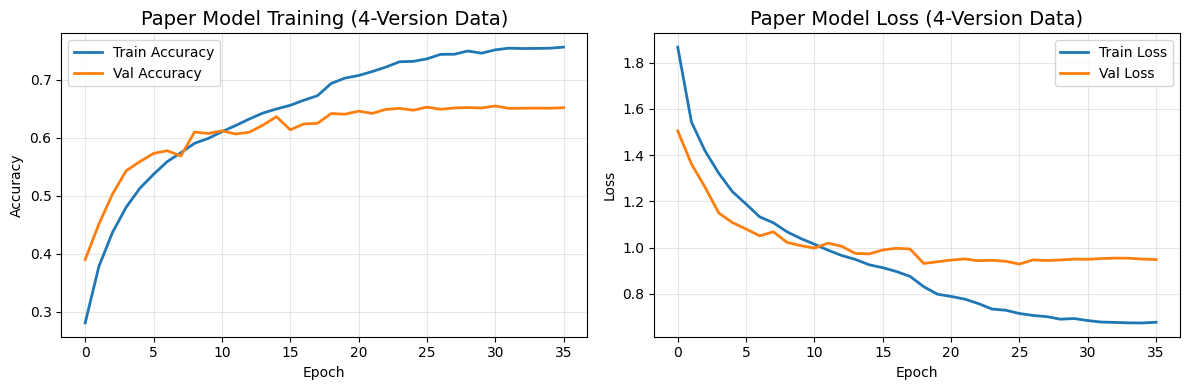


📊 TRAINING STABILITY CHECK
   Final train accuracy: 0.7559
   Final val accuracy: 0.6516
   Train/Val gap: 0.1043
   ⚠️  Moderate overfitting (gap 10-20%)

📋 REDUCED CAPACITY MODEL BENEFITS:
   ✅ Much smaller model (4-8x fewer parameters)
   ✅ L2 regularization on ALL layers
   ✅ 50% dropout everywhere
   ✅ Lower learning rate (0.0005)
   ✅ Weight decay (0.0001)
   ✅ 4x more training samples
   ✅ Better generalization expected
   ✅ Leverages all augmentation types
   ✅ Maintains BiLSTM as requested
   ✅ Should fix overfitting issues


In [0]:
model, history, results = run_paper_experiment_4_versions(train_data, val_data, test_data, label_encoder)

# -----

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

def analyze_model_performance(model, history, results, test_data, label_encoder):
    """
    Essential model performance analysis with key metrics only.
    
    Parameters:
    -----------
    model : keras.Model
        Trained model
    history : keras.History
        Training history
    results : dict
        Evaluation results from evaluate_paper_model_4_versions
    test_data : dict
        Test data dictionary
    label_encoder : sklearn.LabelEncoder
        Label encoder for emotion names
    """
    
    print("📊 ESSENTIAL MODEL PERFORMANCE ANALYSIS")
    print("="*60)
    
    # 1. Training curves
    plot_training_curves(history)
    
    # 2. Confusion matrix
    plot_confusion_matrix(results, label_encoder)
    
    # 3. Per-class metrics
    plot_per_class_metrics(results, label_encoder)
    
    # 4. Print classification report
    print_classification_metrics(results, label_encoder)
    
    print("\n✅ Essential analysis complete!")

def plot_training_curves(history):
    """Plot essential training curves."""
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Training Performance', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['accuracy']) + 1)
    
    # 1. Accuracy
    axes[0].plot(epochs, history.history['accuracy'], 'b-', label='Training', linewidth=2)
    axes[0].plot(epochs, history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Loss
    axes[1].plot(epochs, history.history['loss'], 'b-', label='Training', linewidth=2)
    axes[1].plot(epochs, history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    
    print(f"\n📈 Training Summary:")
    print(f"   Final Training Accuracy: {final_train_acc:.4f}")
    print(f"   Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"   Overfitting Gap: {gap:.4f}")
 

def plot_confusion_matrix(results, label_encoder):
    """Plot confusion matrix."""
    
    y_true = results['true_classes']
    y_pred = results['predicted_classes']
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Confusion Matrix Analysis', fontsize=14, fontweight='bold')
    
    # 1. Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
                ax=axes[0])
    axes[0].set_title('Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # 2. Normalized percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
                ax=axes[1])
    axes[1].set_title('Normalized (by True Class)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

def plot_per_class_metrics(results, label_encoder):
    """Plot per-class performance metrics."""
    
    y_true = results['true_classes']
    y_pred = results['predicted_classes']
    
    # Calculate per-class metrics
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(label_encoder.classes_))
    )
    
    # Also calculate per-class accuracy
    per_class_acc = []
    for i in range(len(label_encoder.classes_)):
        mask = y_true == i
        if np.sum(mask) > 0:
            class_acc = np.mean(y_pred[mask] == y_true[mask])
        else:
            class_acc = 0
        per_class_acc.append(class_acc)
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    
    emotions = label_encoder.classes_
    x_pos = np.arange(len(emotions))
    
    # 1. Accuracy
    bars1 = axes[0,0].bar(x_pos, per_class_acc, color='skyblue', alpha=0.7)
    axes[0,0].set_title('Accuracy by Class')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].set_xticks(x_pos)
    axes[0,0].set_xticklabels(emotions, rotation=45)
    axes[0,0].grid(True, alpha=0.3)
    
    # Add value labels
    for bar, acc in zip(bars1, per_class_acc):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Precision
    bars2 = axes[0,1].bar(x_pos, precision, color='lightcoral', alpha=0.7)
    axes[0,1].set_title('Precision by Class')
    axes[0,1].set_ylabel('Precision')
    axes[0,1].set_xticks(x_pos)
    axes[0,1].set_xticklabels(emotions, rotation=45)
    axes[0,1].grid(True, alpha=0.3)
    
    for bar, prec in zip(bars2, precision):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{prec:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Recall
    bars3 = axes[1,0].bar(x_pos, recall, color='lightgreen', alpha=0.7)
    axes[1,0].set_title('Recall by Class')
    axes[1,0].set_ylabel('Recall')
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels(emotions, rotation=45)
    axes[1,0].grid(True, alpha=0.3)
    
    for bar, rec in zip(bars3, recall):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{rec:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. F1-Score
    bars4 = axes[1,1].bar(x_pos, f1, color='gold', alpha=0.7)
    axes[1,1].set_title('F1-Score by Class')
    axes[1,1].set_ylabel('F1-Score')
    axes[1,1].set_xticks(x_pos)
    axes[1,1].set_xticklabels(emotions, rotation=45)
    axes[1,1].grid(True, alpha=0.3)
    
    for bar, f1_score in zip(bars4, f1):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{f1_score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def print_classification_metrics(results, label_encoder):
    """Print detailed classification report and key statistics."""
    
    y_true = results['true_classes']
    y_pred = results['predicted_classes']
    
    print(f"\n📊 CLASSIFICATION REPORT:")
    print("="*70)
    
    # Detailed classification report
    report = classification_report(
        y_true, y_pred, 
        target_names=label_encoder.classes_, 
        digits=4
    )
    print(report)
    
    # Overall metrics
    overall_accuracy = results['accuracy']
    print(f"\n🎯 OVERALL PERFORMANCE:")
    print(f"   Test Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
    print(f"   Total Test Samples: {len(y_true):,}")
    print(f"   Correct Predictions: {np.sum(y_pred == y_true):,}")
    
    # Per-version performance (if available)
    if 'original_test_size' in results:
        print(f"\n🔄 PERFORMANCE BY DATA VERSION:")
        print("-" * 40)
        
        original_test_size = results['original_test_size']
        versions = ['Normal', 'Noise', 'Pitch', 'Combined']
        
        for i, version in enumerate(versions):
            start_idx = i * original_test_size
            end_idx = (i + 1) * original_test_size
            
            version_pred = y_pred[start_idx:end_idx]
            version_true = y_true[start_idx:end_idx]
            version_acc = np.mean(version_pred == version_true)
            
            print(f"   {version:>10}: {version_acc:.4f} ({version_acc*100:5.1f}%)")
    
    # Best and worst performing classes
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(label_encoder.classes_))
    )
    
    # Create emotion-score pairs and sort
    emotion_f1_pairs = list(zip(label_encoder.classes_, f1))
    emotion_f1_pairs.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n🏆 EMOTION RECOGNITION RANKING (by F1-Score):")
    print("-" * 50)
    for rank, (emotion, f1_score) in enumerate(emotion_f1_pairs, 1):
        print(f"   {rank:2}. {emotion:>10}: {f1_score:.4f}")
    
    print(f"\n💡 KEY INSIGHTS:")
    print("-" * 30)
    print(f"   🏆 Best performing emotion: {emotion_f1_pairs[0][0]} (F1: {emotion_f1_pairs[0][1]:.3f})")
    print(f"   🔥 Most challenging emotion: {emotion_f1_pairs[-1][0]} (F1: {emotion_f1_pairs[-1][1]:.3f})")
    print(f"   📊 F1-Score range: {emotion_f1_pairs[-1][1]:.3f} - {emotion_f1_pairs[0][1]:.3f}")
    print(f"   🎯 Macro-average F1: {np.mean(f1):.3f}")

# Main function to call
def essential_analysis(model, history, results, test_data, label_encoder):
    """
    Run essential performance analysis.
    
    Usage after training:
    essential_analysis(model, history, results, test_data, label_encoder)
    """
    analyze_model_performance(model, history, results, test_data, label_encoder)

📋 ESSENTIAL MODEL PERFORMANCE ANALYSIS
🎯 Includes:
   • Training curves (accuracy & loss)
   • Confusion matrix (raw & normalized)
   • Per-class metrics (accuracy, precision, recall, F1)
   • Classification report
   • Performance ranking by emotion
   • Key insights summary

🚀 Usage:
   essential_analysis(model, history, results, test_data, label_encoder)


📊 ESSENTIAL MODEL PERFORMANCE ANALYSIS


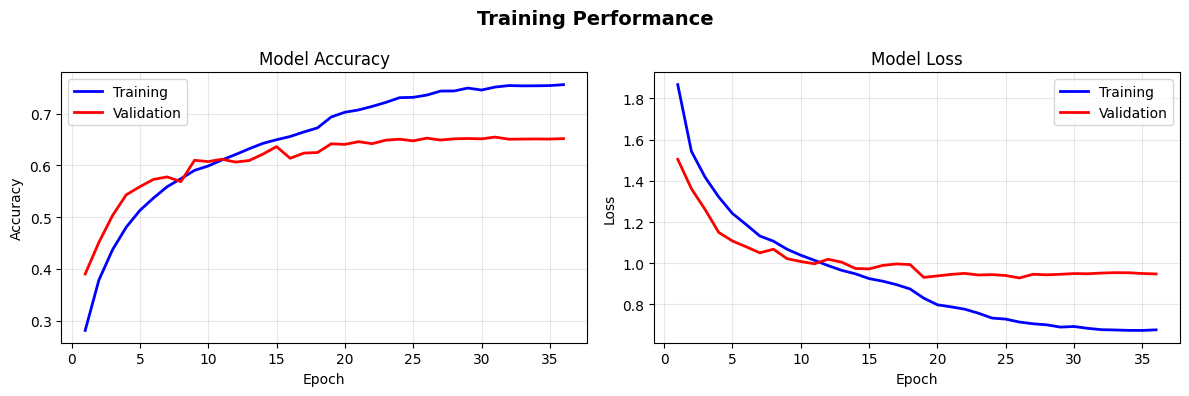


📈 Training Summary:
   Final Training Accuracy: 0.7559
   Final Validation Accuracy: 0.6516
   Overfitting Gap: 0.1043
   ⚠️  Moderate overfitting


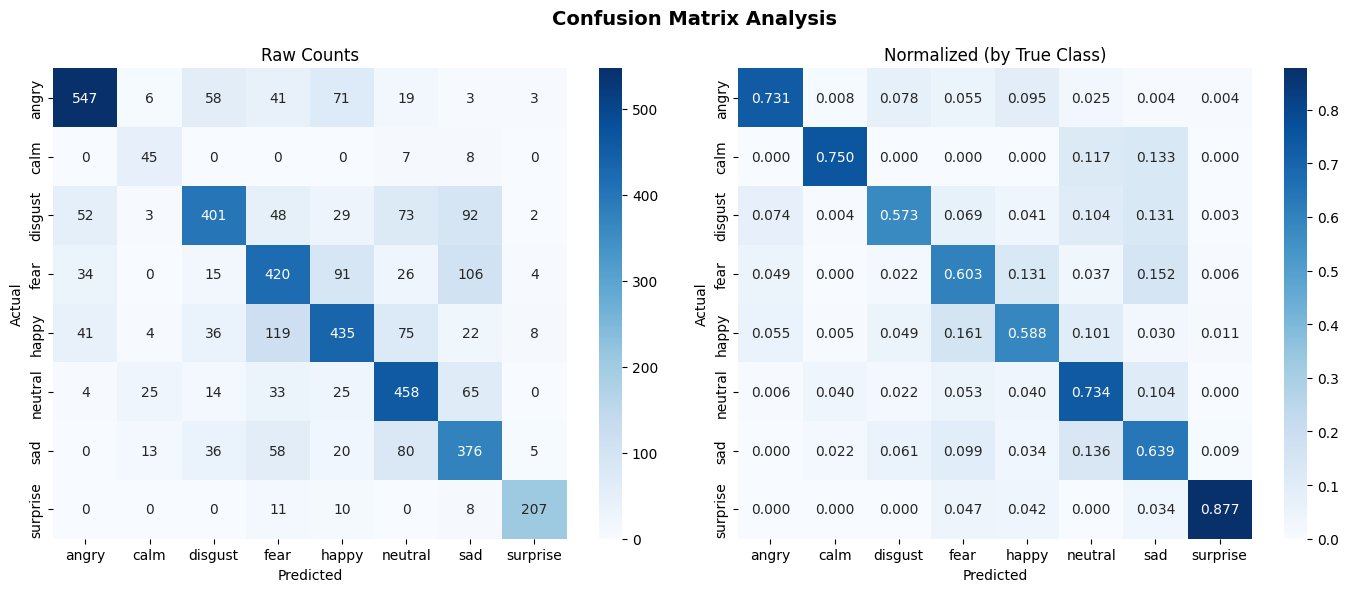

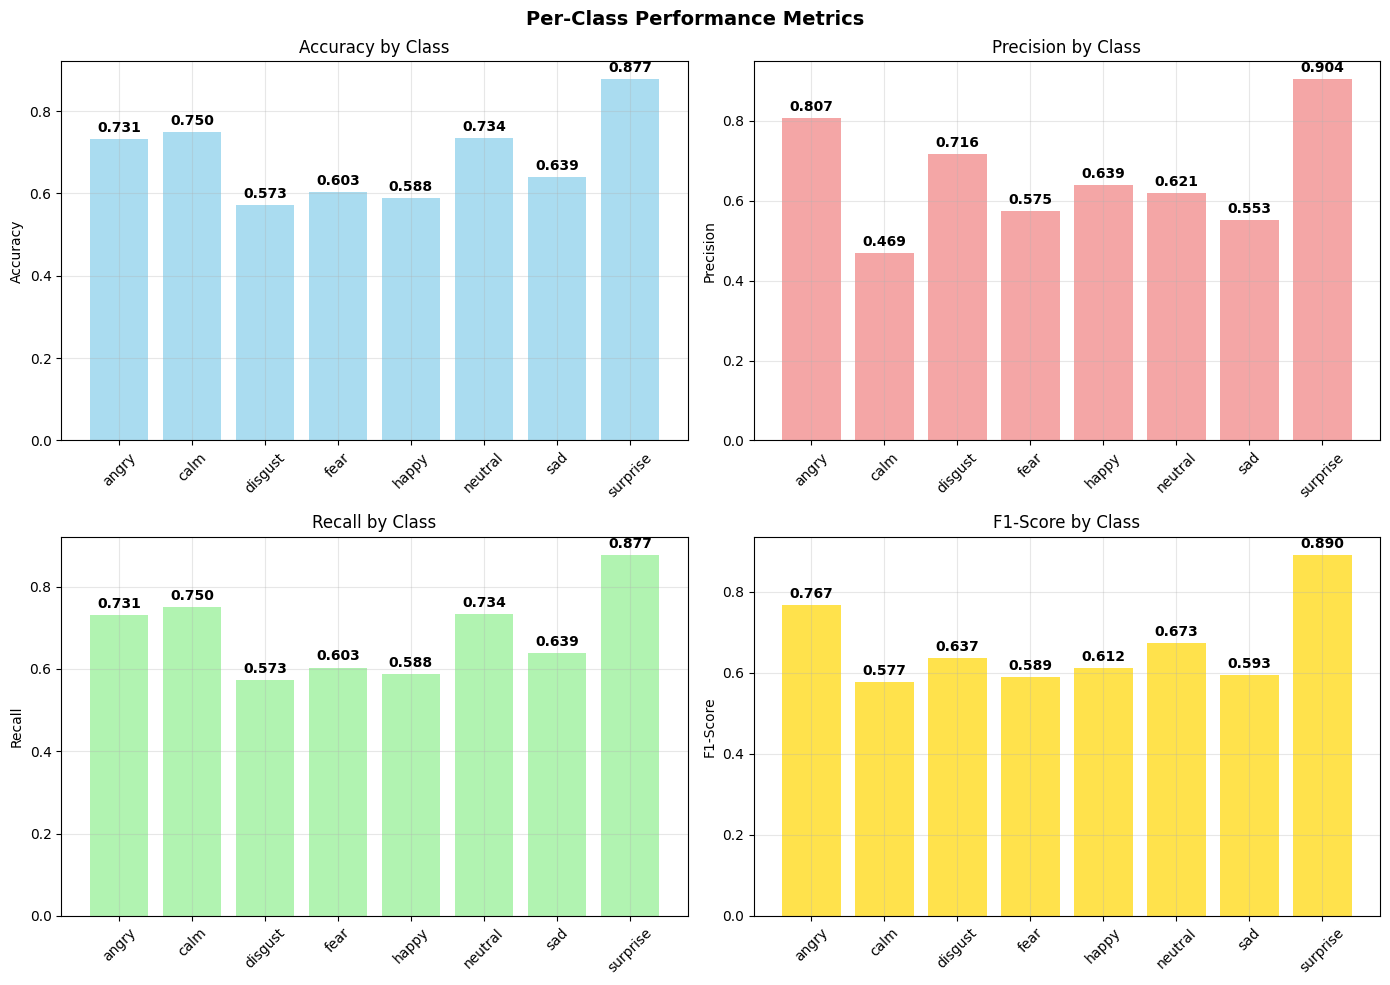


📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       angry     0.8068    0.7313    0.7672       748
        calm     0.4688    0.7500    0.5769        60
     disgust     0.7161    0.5729    0.6365       700
        fear     0.5753    0.6034    0.5891       696
       happy     0.6388    0.5878    0.6122       740
     neutral     0.6206    0.7340    0.6725       624
         sad     0.5529    0.6395    0.5931       588
    surprise     0.9039    0.8771    0.8903       236

    accuracy                         0.6578      4392
   macro avg     0.6604    0.6870    0.6672      4392
weighted avg     0.6675    0.6578    0.6593      4392


🎯 OVERALL PERFORMANCE:
   Test Accuracy: 0.6578 (65.78%)
   Total Test Samples: 4,392
   Correct Predictions: 2,889

🔄 PERFORMANCE BY DATA VERSION:
----------------------------------------
       Normal: 0.6703 ( 67.0%)
        Noise: 0.6648 ( 66.5%)
        Pitch: 0.6439 ( 64.4%)
     Combined: 0.6521 ( 65.2%)

🏆 EMOTIO

In [0]:
essential_analysis(model, history, results, test_data, label_encoder)


In [0]:
import os
import json
import joblib

def save_for_inference(model, label_encoder, scalers, save_dir='/Workspace/Users/dimnaishvili@tbcbank.com.ge/f/audio_results'):
    """Save essential files for inference."""
    
    os.makedirs(save_dir, exist_ok=True)
    
    # Save model
    model.save(f'{save_dir}/emotion_model.h5')
    
    # Save label encoder and scalers
    joblib.dump(label_encoder, f'{save_dir}/label_encoder.pkl')
    joblib.dump(scalers, f'{save_dir}/scalers.pkl')
    
    # Save preprocessing config
    config = {
        'sampling_rate': 16000,
        'frame_length': 2048,
        'hop_length': 512,
        'audio_duration': 2.5,
        'offset': 0.6,
        'n_mfcc': 13,
        'n_chroma': 12,
        'sequence_length': 79,
        'n_features': 53,
        'emotions': list(label_encoder.classes_)
    }
    
    with open(f'{save_dir}/config.json', 'w') as f:
        json.dump(config, f)

# Usage:
save_for_inference(model, label_encoder, scalers)